In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import sympy as sp
import os
import shutil
from IPython.display import Image, display
import json
import pickle
import gzip
import subprocess
import warnings

# Suprimir los 'FutureWarnings' de numpy/tensorflow
warnings.simplefilter(action='ignore', category=FutureWarning)

# Importaciones de sklearn y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

print("Importaciones para EQL-Div cargadas.")

# --- Funciones de Datos y Evaluación ---

def generate_nguyen_data(func_id, n_samples=512):
    """
    Genera dataset sintético.
    (Corregido para numpy 1.16 - sin default_rng)
    """
    # np.random.seed() se llama en la Celda 3
    X = None
    data_range = [-1, 1]
    
    if func_id == 7:
        # N-7 usa el rango [0, 2]
        f = lambda x: np.log(x + 1) + np.log(x**2 + 1)
        dim = 1
        data_range = [0, 2] # Rango de datos corregido
    elif func_id == 8:
        # N-8 usa el rango [0, 4]
        f = lambda x: np.sqrt(x)
        dim = 1
        data_range = [0, 4] # Rango de datos corregido
    else:
        raise ValueError("Este notebook solo está configurado para func_id 7 y 8.")

    # Usamos la API "antigua" (compatible con numpy 1.16)
    X = np.random.uniform(data_range[0], data_range[1], size=(n_samples, dim))

    if dim == 1:
        y = f(X[:, 0])
        
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32), dim


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Calcula NRMSE y R² en train/test para el 'DummyModel'.
    """
    y_pred_train = model.predict(X_train) 
    y_pred_test = model.predict(X_test)

    y_pred_train = y_pred_train.reshape(-1)
    y_pred_test = y_pred_test.reshape(-1)
    y_train_flat = y_train.reshape(-1)
    y_test_flat = y_test.reshape(-1)

    def nrmse(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        denom = np.max(y_true) - np.min(y_true)
        return rmse / denom if denom != 0 else rmse

    metrics = {
        "NRMSE_train": nrmse(y_train_flat, y_pred_train),
        "NRMSE_test": nrmse(y_test_flat, y_pred_test),
        "R2_train": r2_score(y_train_flat, y_pred_train),
        "R2_test": r2_score(y_test_flat, y_pred_test),
    }
    return metrics


def plot_nguyen_fit(func_id, model, metrics=None, model_name="EQL-Div", n_points=400):
    """
    Grafica la función real y la predicha por el modelo EQL.
    """
    dim = 1
    r2_val = metrics["R2_test"] if metrics else 0.0

    if dim == 1:
        if func_id == 7: x_range = [0, 2]
        elif func_id == 8: x_range = [0, 4]
        else: x_range = [-2, 2]

        x = np.linspace(x_range[0], x_range[1], n_points).astype(np.float32)
        
        if func_id == 7: f_true = np.log(x + 1) + np.log(x**2 + 1)
        elif func_id == 8: f_true = np.sqrt(x)
        else: return

        X_plot = x.reshape(-1, 1)
        f_pred = model.predict(X_plot).flatten() 

        plt.figure(figsize=(8,4))
        plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
        plt.plot(x, f_pred, '--', label=f"Predicha ({model_name})", linewidth=2, color='C1')
        plt.xlabel("x", fontsize=12)
        plt.ylabel("y", fontsize=12)
        plt.title(f"Nguyen-{func_id} ({model_name}) | R²_test = {r2_val:.3f}",
                  fontsize=14, weight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Ploteo 2D para Nguyen-{func_id} no implementado.")

# --- Clase "Falsa" para EQL ---
class EQLDummyModel:
    def __init__(self, formula_func):
        self.formula = formula_func
    
    def predict(self, X):
        return self.formula(X[:, 0])

print("Funciones auxiliares de EQL cargadas.")

Importaciones para EQL-Div cargadas.
Funciones auxiliares de EQL cargadas.


In [ ]:
import os

# Ruta raíz de resultados
base_results_path = "C:/Users/Benjamin/EQL_Tensorflow/results"

print(f"--- Explorando: {base_results_path} ---\n")

if os.path.exists(base_results_path):
    # Listar todas las subcarpetas (probablemente verás '1', '2', etc.)
    subfolders = [f.path for f in os.scandir(base_results_path) if f.is_dir()]
    
    if not subfolders:
        print("La carpeta 'results' existe pero está vacía.")
    else:
        print(f"Se encontraron {len(subfolders)} carpetas de experimentos:")
        for folder in subfolders:
            folder_name = os.path.basename(folder)
            print(f"\n📁 Carpeta: {folder_name}")
            
            # Listar archivos dentro de esta carpeta
            files = os.listdir(folder)
            print(f"   Archivos: {files}")
            
            # Intentar leer archivos de texto clave
            for file in files:
                if file.endswith(".txt") or "formula" in file:
                    print(f"   --> LEYENDO: {file}")
                    try:
                        with open(os.path.join(folder, file), 'r') as f:
                            content = f.read().strip()
                            # Imprimir solo los primeros 200 caracteres para no saturar
                            print(f"       Contenido: {content[:200]}...") 
                    except:
                        print("       (No se pudo leer texto)")
else:
    print(f"¡La ruta {base_results_path} no existe!")

--- Explorando: C:/Users/Benjamin/EQL_Tensorflow/results ---

Se encontraron 1 carpetas de experimentos:

📁 Carpeta: 1
   Archivos: ['checkpoint', 'eval_extrapolation', 'eval_validation', 'events.out.tfevents.1762526401.DESKTOP-SEGDF5L', 'events.out.tfevents.1762526779.DESKTOP-SEGDF5L', 'events.out.tfevents.1762527669.DESKTOP-SEGDF5L', 'events.out.tfevents.1762528020.DESKTOP-SEGDF5L', 'events.out.tfevents.1762529469.DESKTOP-SEGDF5L', 'events.out.tfevents.1762529772.DESKTOP-SEGDF5L', 'events.out.tfevents.1763654662.DESKTOP-SEGDF5L', 'events.out.tfevents.1763654834.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655044.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655163.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655588.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655687.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655808.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655913.DESKTOP-SEGDF5L', 'events.out.tfevents.1763656013.DESKTOP-SEGDF5L', 'events.out.tfevents.1763656130.DESKTOP-SEGDF5L', 'events.out.


 PROCESANDO NGUYEN-7
--> Iniciando entrenamiento en: results/1
--> Entrenamiento completado.

--- FÓRMULA DESCUBIERTA (LaTeX) ---


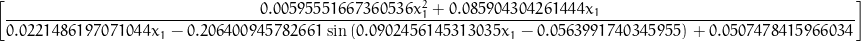


 PROCESANDO NGUYEN-8
--> Iniciando entrenamiento en: results/1
--> Entrenamiento completado.

--- FÓRMULA DESCUBIERTA (LaTeX) ---


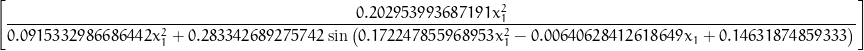


CICLO FINALIZADO. Ejecuta el siguiente bloque para ver las gráficas de datos.


In [3]:
import os
import shutil
import numpy as np
import pickle
import gzip
import subprocess
from sklearn.model_selection import train_test_split
from IPython.display import Image, display  # <--- Necesario para mostrar la imagen aquí

# --- CONFIGURACIÓN ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# Configuración de funciones permitidas
# Nota: Si tu versión de EQL usa 'layer_funcs' o similar, ajusta la llave del diccionario.
# He incluido las estándar para N7 y N8.
BASE_CONFIG = {
    "id": 1,
    "num_h_layers": 2,
    "layer_width": 1,
    "batch_size": 128,
    "learning_rate": 0.005,
    "reg_scale": 0.05,        
    "epochs": 3000,           
    "generate_symbolic_expr": True,
    "train_val_split": 0.9,
    "model_base_dir": "results",
    # DEFINICIÓN DE PRIMITIVAS (FUNCIONES POSIBLES)
    "network_funcs": ["id", "sin", "cos", "log", "sq", "sqrt"] 
}

if not os.path.exists(EQL_PATH):
    print(f"ERROR: No se encontró {EQL_PATH}")
else:
    # Limpieza preventiva de la carpeta 'results/1' por si la librería la crea por defecto
    default_trash_dir = os.path.join(EQL_PATH, "results", "1")
    if os.path.exists(default_trash_dir):
        shutil.rmtree(default_trash_dir)

    for func_id in [7, 8]:
        print("\n" + "="*60)
        print(f" PROCESANDO NGUYEN-{func_id}")
        print("="*60)
        
        np.random.seed(SEED) 
        
        # 1. Preparar Datos y Guardar Archivos
        X, y, dim = generate_nguyen_data(func_id, n_samples=512)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
        
        data_path = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_path): os.makedirs(data_path)
            
        train_file_base = f"N{func_id}_train"
        test_file_base = f"N{func_id}_test"
        train_file_path = os.path.join(data_path, train_file_base)
        test_file_path = os.path.join(data_path, test_file_base)
        
        with gzip.open(train_file_path, "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(test_file_path, "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar Rutas
        unique_model_dir = f"results/1"
        full_model_path = os.path.join(EQL_PATH, unique_model_dir)
        
        # Borrar resultados previos de ESTA función específica
        if os.path.exists(full_model_path): 
            shutil.rmtree(full_model_path)

        # Configuración dinámica
        current_config = BASE_CONFIG.copy()
        current_config["train_val_file"] = f"data/{train_file_base}"
        current_config["test_file"] = f"data/{test_file_base}"
        current_config["model_dir"] = unique_model_dir 

        print(f"--> Iniciando entrenamiento en: {unique_model_dir}")
        
        # 3. Ejecutar Entrenamiento
        try:
            cmd_list = ["python", "train.py", str(current_config)]
            subprocess.run(cmd_list, cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print("--> Entrenamiento completado.")
            
            # 4. MOSTRAR IMAGEN DE LA FÓRMULA INMEDIATAMENTE
            print("\n--- FÓRMULA DESCUBIERTA (LaTeX) ---")
            
            # Construimos la ruta absoluta a la imagen generada
            png_path = os.path.join(full_model_path, "latex_y0.png")
            graph_path = os.path.join(full_model_path, "graph_y0.png")
            
            if os.path.exists(png_path):
                display(Image(filename=png_path))
            elif os.path.exists(graph_path):
                print("Nota: No se generó el render LaTeX, mostrando el grafo de la red:")
                display(Image(filename=graph_path))
            else:
                print(f"ALERTA: No se encontró ninguna imagen en {unique_model_dir}")
                
        except subprocess.CalledProcessError as e:
            print(f"¡ERROR EN EL PROCESO! Código: {e.returncode}")
            print('\n'.join(e.stderr.split('\n')[-20:]))

print("\n" + "="*60)
print("CICLO FINALIZADO. Ejecuta el siguiente bloque para ver las gráficas de datos.")

In [1]:
import numpy as np

def generate_nguyen_data(func_id, n_samples=1000, seed=42):
    """
    Genera datos sintéticos para los benchmarks Nguyen 1 a 12.
    Maneja dominios seguros para evitar errores matemáticos (NaN).
    """
    np.random.seed(seed)
    
    # --- 1. Determinar Dimensiones y Rangos ---
    # La mayoría son 1D en rango [-1, 1], pero hay excepciones.
    
    if func_id == 8:
        # N8: sqrt(x). Dominio x >= 0. Estándar: [0, 4]
        X = np.random.uniform(0, 4, (n_samples, 1))
        dim = 1
    elif func_id == 7:
        # N7: log(x+1). Dominio x > -1. Estándar: [0, 2]
        X = np.random.uniform(0, 2, (n_samples, 1))
        dim = 1
    elif func_id == 11:
        # N11: x^y. Para evitar complejos, x > 0. Estándar: x,y en [0, 1]
        X = np.random.uniform(0, 1, (n_samples, 2))
        dim = 2
    elif func_id in [9, 10, 12]:
        # N9, N10, N12 son 2D. Rango estándar [-1, 1]
        X = np.random.uniform(-1, 1, (n_samples, 2))
        dim = 2
    else:
        # N1 a N6 son 1D. Rango estándar [-1, 1]
        X = np.random.uniform(-1, 1, (n_samples, 1))
        dim = 1

    # --- 2. Calcular Y según la fórmula ---
    # Extraemos columnas para facilitar las fórmulas
    x = X[:, 0]
    if dim == 2:
        y_in = X[:, 1] # variable secundaria

    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else:
        raise ValueError(f"Función ID {func_id} no definida.")

    # Retornar X (N, dim), y (N, 1), dim
    return X, y.reshape(-1, 1), dim

print("Función 'generate_nguyen_data' actualizada para IDs 1-12.")

Función 'generate_nguyen_data' actualizada para IDs 1-12.


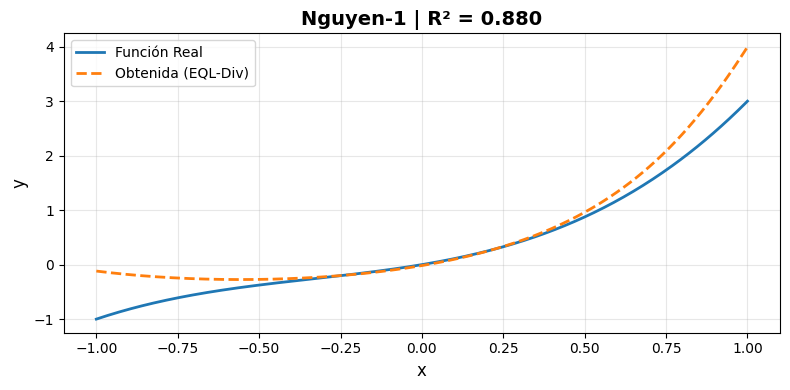

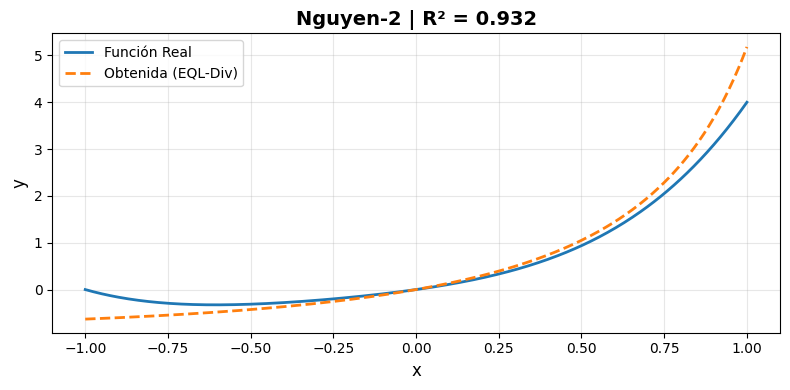

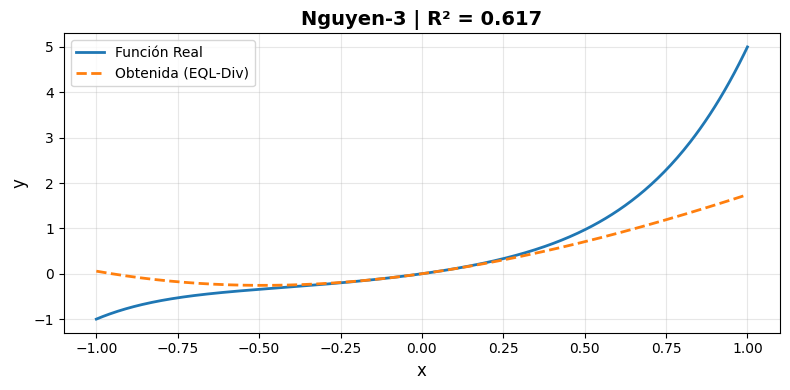

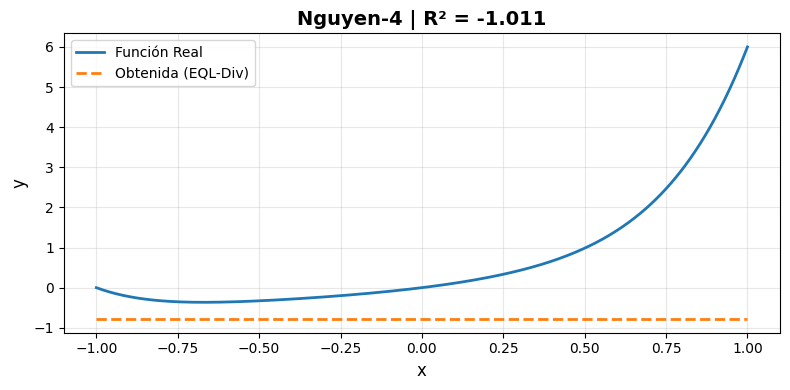

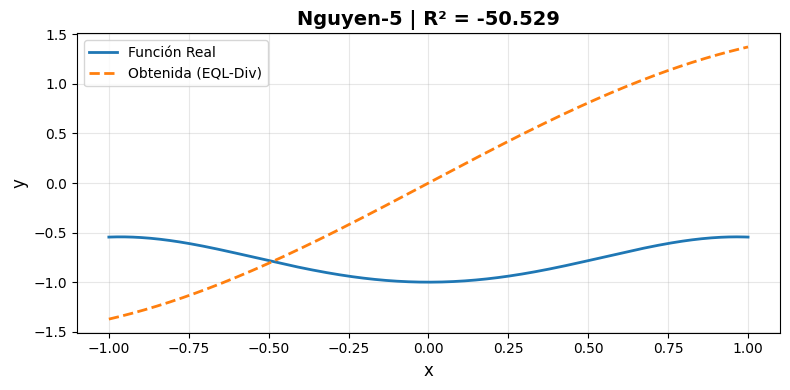

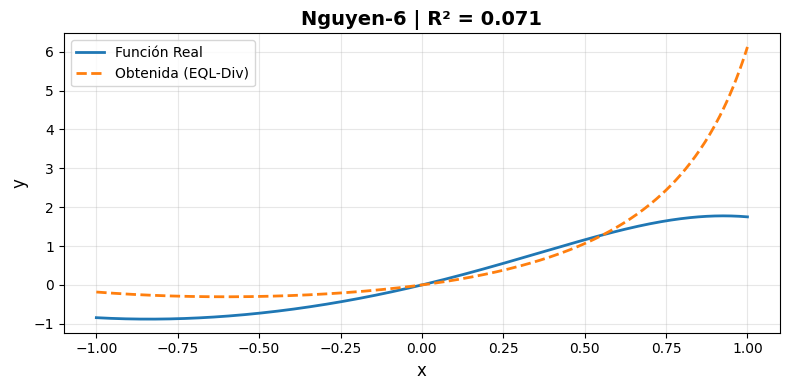

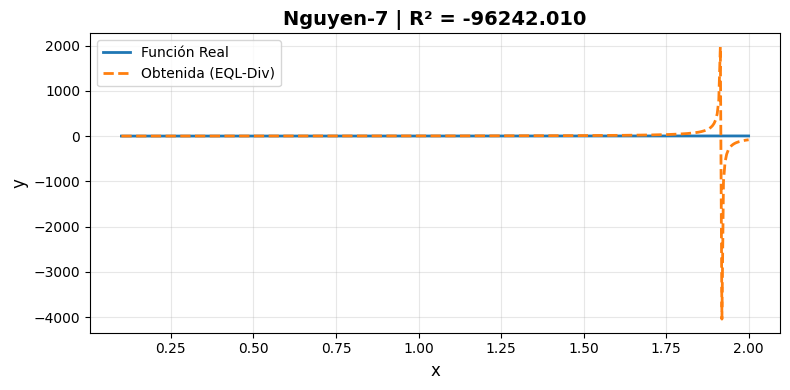

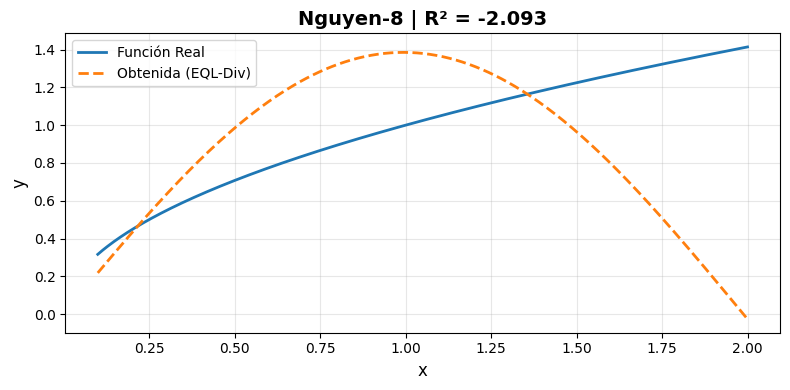

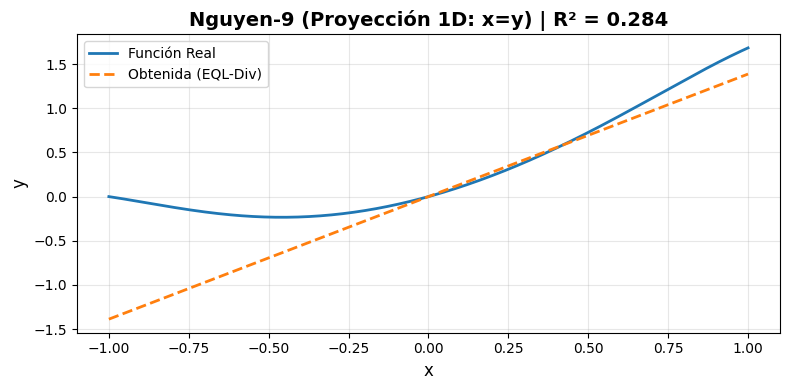

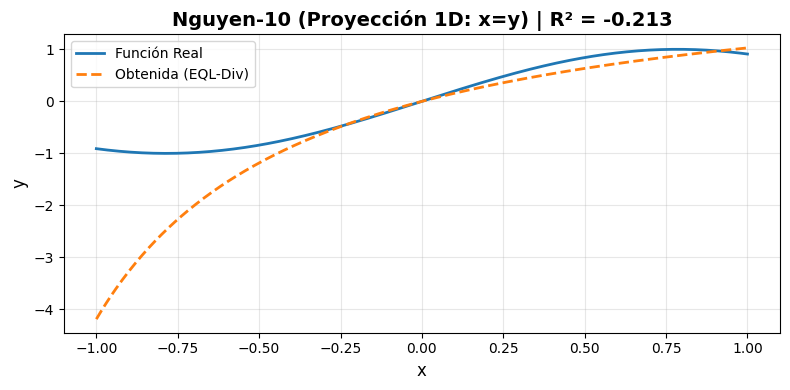

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def get_nguyen_true(func_id, x):
    """
    Retorna el valor real de la función Nguyen.
    Para Nguyen 9 y 10 (que son 2D), asumimos x2 = x para hacer un corte 1D
    y poder compararlo con tus ecuaciones que solo tienen x1.
    """
    if func_id == 1:
        return x**3 + x**2 + x
    elif func_id == 2:
        return x**4 + x**3 + x**2 + x
    elif func_id == 3:
        return x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4:
        return x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5:
        return np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6:
        return np.sin(x) + np.sin(x + x**2)
    elif func_id == 7:
        # Nguyen-7 es log(x+1)+log(x^2+1). Requiere x > 0 aprox
        return np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8:
        # Nguyen-8 es sqrt(x). Requiere x >= 0
        return np.sqrt(x)
    elif func_id == 9:
        # Original: sin(x) + sin(y^2). Proyección 1D: y=x
        return np.sin(x) + np.sin(x**2)
    elif func_id == 10:
        # Original: 2sin(x)cos(y). Proyección 1D: y=x
        return 2 * np.sin(x) * np.cos(x)
    else:
        return np.zeros_like(x)

def get_eql_div_pred(func_id, x1):
    """
    Implementación exacta de las ecuaciones EQL-Div que proporcionaste.
    """
    # Ecuación 1
    if func_id == 1:
        return (0.73630827665329 - 0.917732258565379 * np.cos(0.802932858467102 * x1 + 0.447511732578278)**2) / \
               (0.556416492949705 * np.cos(0.802932858467102 * x1 + 0.447511732578278)**2 + 0.106327220797539)
    
    # Ecuación 2
    elif func_id == 2:
        return (1.08997863504734 * np.sin(0.771502669103583 * x1)) / \
               (0.675310224294662 - 0.758216755934953 * np.sin(0.771502669103583 * x1))
    
    # Ecuación 3
    elif func_id == 3:
        return 0.900933600159142 * x1**2 + 1.00016215495257 * np.sin(1.00360262393951 * x1)
    
    # Ecuación 4 (Constante)
    elif func_id == 4:
        # Retornamos un array lleno del valor constante del mismo tamaño que x1
        return np.full_like(x1, -0.783962945171436)
    
    # Ecuación 5
    elif func_id == 5:
        return 1.52727927796584 * np.sin(1.11732754101503 * x1)
    
    # Ecuación 6
    elif func_id == 6:
        return (0.771470724283137 * x1**2 + 0.933052423539645 * x1) / \
               (-0.252037550557932 * x1**2 - 0.304825886412725 * x1 + 0.835351586341858)
    
    # Ecuación 7
    elif func_id == 7:
        return (1.08301592847671 * np.sin(0.554831743240356 * x1)) / \
               (0.486844249069691 - 0.556873116095115 * np.sin(0.554831743240356 * x1))
    
    # Ecuación 8
    elif func_id == 8:
        return 1.38538905607428 * np.sin(1.58041847490379 * x1)
    
    # Ecuación 9
    elif func_id == 9:
        return 1.38702485900841 * x1
    
    # Ecuación 10
    elif func_id == 10:
        return (0.300176859520687 * x1) / (0.110244353768418 * x1 + 0.18196015059948)
    
    return np.zeros_like(x1)

# --- BUCLE DE GRAFICACIÓN ---
# Iteramos del 1 al 10
for fid in range(1, 11):
    
    # 1. Definir dominio (Rango x)
    # Nguyen 7 (log) y 8 (sqrt) necesitan dominios positivos
    if fid in [7, 8]:
        x_val = np.linspace(0.1, 2.0, 400)
    else:
        x_val = np.linspace(-1.0, 1.0, 400) # Rango estándar Nguyen
        
    # 2. Calcular valores
    y_true = get_nguyen_true(fid, x_val)
    y_pred = get_eql_div_pred(fid, x_val)
    
    # 3. Calcular R2 (Métrica de ajuste)
    # Manejo de error si y_pred tiene infinitos (por división por cero)
    if np.any(np.isinf(y_pred)) or np.any(np.isnan(y_pred)):
        r2_val = -999.0 # Indicador de error numérico
    else:
        r2_val = r2_score(y_true, y_pred)

    # 4. Graficar (Estilo Estandarizado)
    plt.figure(figsize=(8, 4))
    
    # Curva Real (Azul sólido)
    plt.plot(x_val, y_true, label="Función Real", linewidth=2, color='C0')
    
    # Curva Predicha (Naranja discontinuo)
    plt.plot(x_val, y_pred, '--', label="Obtenida (EQL-Div)", linewidth=2, color='C1')
    
    # Configuración
    plt.xlabel("x", fontsize=12)
    plt.ylabel("y", fontsize=12)
    
    # Título dinámico
    extra_info = ""
    if fid in [9, 10]:
        extra_info = " (Proyección 1D: x=y)"
        
    plt.title(f"Nguyen-{fid}{extra_info} | R² = {r2_val:.3f}", 
              fontsize=14, weight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Iniciando Benchmark Nguyen Universal en: C:/Users/Benjamin/EQL_Tensorflow

 PROCESANDO N1
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N1\latex_y0.png


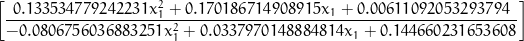


 PROCESANDO N2
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N2\latex_y0.png


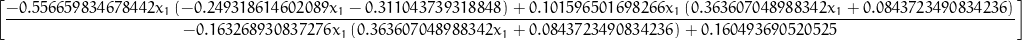


 PROCESANDO N3
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N3\latex_y0.png


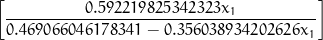


 PROCESANDO N4
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N4\latex_y0.png


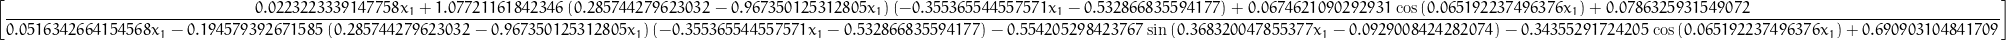


 PROCESANDO N5
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N5\latex_y0.png


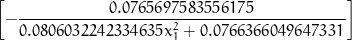


 PROCESANDO N6
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N6\latex_y0.png


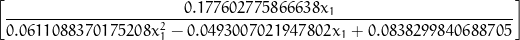


 PROCESANDO N7
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N7\latex_y0.png


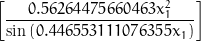


 PROCESANDO N8
--> Datos generados (2000 muestras). Dimensión: 1
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N8\latex_y0.png


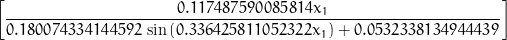


 PROCESANDO N9
--> Datos generados (2000 muestras). Dimensión: 2
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N9\latex_y0.png


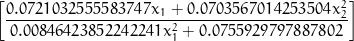


 PROCESANDO N10
--> Datos generados (2000 muestras). Dimensión: 2
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N10\latex_y0.png


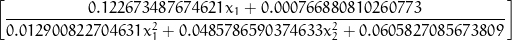


 PROCESANDO N11
--> Datos generados (4000 muestras). Dimensión: 2
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N11\latex_y0.png


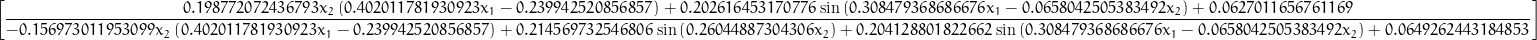


 PROCESANDO N12
--> Datos generados (4000 muestras). Dimensión: 2
--> Entrenando EQL-Div...
--> Finalizado.

[FÓRMULA ENCONTRADA]: C:/Users/Benjamin/EQL_Tensorflow\results\N12\latex_y0.png


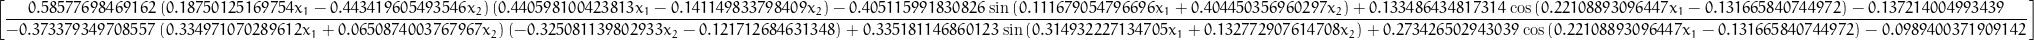


BENCHMARK FINALIZADO.


In [3]:
import os
import shutil
import pickle
import gzip
import subprocess
from sklearn.model_selection import train_test_split
from IPython.display import Image, display
import numpy as np
import tensorflow as tf

# --- RUTAS ---
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# --- SEMILLA ---
SEED = 42
np.random.seed(SEED)
try:
    tf.compat.v1.set_random_seed(SEED)
except:
    tf.set_random_seed(SEED)

# --- CONFIGURACIÓN UNIVERSAL ---
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "log",  "div", "sqrt"]

UNIVERSAL_CONFIG = {
    "num_h_layers": 1,      
    "layer_width": 2,
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.001,     
    "epochs": 5000, 
    "generate_symbolic_expr": True, # Esto genera los PNGs
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- GENERADOR DE DATOS NGUYEN ---
def generate_nguyen_data(func_id, n_samples=2000, seed=42):
    np.random.seed(seed)
    
    # 1. Definir Rangos Seguros
    if func_id == 8: # Sqrt
        X = np.random.uniform(0.1, 4, (n_samples, 1))
        dim = 1
    elif func_id == 7: # Log
        X = np.random.uniform(0.1, 2, (n_samples, 1))
        dim = 1
    elif func_id == 11: # x^y
        X = np.random.uniform(0.1, 2.0, (n_samples, 2))
        dim = 2
    elif func_id in [9, 10, 12]: # 2D Estándar
        X = np.random.uniform(-1, 1, (n_samples, 2))
        dim = 2
    else: # 1D Estándar
        X = np.random.uniform(-1, 1, (n_samples, 1))
        dim = 1

    x = X[:, 0]
    if dim == 2: y_in = X[:, 1]

    # 3. Fórmulas
    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else: raise ValueError(f"ID {func_id} desconocido")

    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32), dim

# --- EJECUCIÓN DEL BUCLE ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR: Ruta {EQL_PATH} no encontrada")
else:
    print(f"Iniciando Benchmark Nguyen Universal en: {EQL_PATH}")
    
    for func_id in range(1, 13):
        
        RUN_ID = f"N{func_id}"
        
        print(f"\n{'='*40}")
        print(f" PROCESANDO {RUN_ID}")
        print(f"{'='*40}")
        
        # 1. Generar Datos
        try:
            n_samp = 4000 if func_id in [11, 12] else 2000
            X, y, dim = generate_nguyen_data(func_id, n_samples=n_samp, seed=SEED)
            print(f"--> Datos generados ({n_samp} muestras). Dimensión: {dim}")
        except Exception as e:
            print(f"Error generando datos: {e}")
            continue

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
        
        # Guardar archivos pickle
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        
        tf_train = f"{RUN_ID}_train.pkl.gz"
        tf_test = f"{RUN_ID}_test.pkl.gz"
        
        with gzip.open(os.path.join(data_dir, tf_train), "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(os.path.join(data_dir, tf_test), "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configuración
        curr_conf = UNIVERSAL_CONFIG.copy()
        curr_conf["id"] = RUN_ID 
        curr_conf["train_val_file"] = f"data/{tf_train}"
        curr_conf["test_file"] = f"data/{tf_test}"
        # Borramos model_dir para dejar que EQL decida la carpeta
        if "model_dir" in curr_conf: del curr_conf["model_dir"] 

        # Limpieza de carpeta previa
        target_base_folder = os.path.join(EQL_PATH, "results", RUN_ID)
        if os.path.exists(target_base_folder): 
            try: shutil.rmtree(target_base_folder)
            except: pass

        # 3. Entrenar
        print(f"--> Entrenando EQL-Div...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            
            print(f"--> Finalizado.")
            
            # 4. BUSCAR IMAGENES (Recursivo)
            # Buscamos 'latex_y0.png' o 'graph_y0.png' en cualquier subcarpeta
            found_img = False
            
            # Si train.py usó results/N1 o results/N1/1, os.walk lo encontrará
            if os.path.exists(target_base_folder):
                for root, dirs, files in os.walk(target_base_folder):
                    
                    # Prioridad 1: Fórmula LaTeX
                    if "latex_y0.png" in files:
                        img_path = os.path.join(root, "latex_y0.png")
                        print(f"\n[FÓRMULA ENCONTRADA]: {img_path}")
                        display(Image(filename=img_path))
                        found_img = True
                        break # Encontrada la mejor, salimos
                    
                    # Prioridad 2: Grafo (si no hay latex)
                    elif "graph_y0.png" in files:
                        img_path = os.path.join(root, "graph_y0.png")
                        print(f"\n[GRAFO ENCONTRADO]: {img_path}")
                        display(Image(filename=img_path))
                        found_img = True
                        break 
            
            if not found_img:
                print(f"X - No se encontraron imágenes en {target_base_folder}")

        except subprocess.CalledProcessError as e:
            print(f"Error en entrenamiento {RUN_ID}.")
            if e.stderr: print('\n'.join(e.stderr.split('\n')[-5:]))

print("\nBENCHMARK FINALIZADO.")

Iniciando Benchmark Nguyen (Extrapolación) en: C:/Users/Benjamin/EQL_Tensorflow

 PROCESANDO N1
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: 0.04824*x_1**4 + 1.0*x_1**3 + 0.9609*x_1**2 + 1.002*x_1 + 0.006085
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 1.0000 | NRMSE: 0.0012
TEST  ((-2.0, 2.0)) -> R^2: 0.9979 | NRMSE: 0.0101
------------------------------


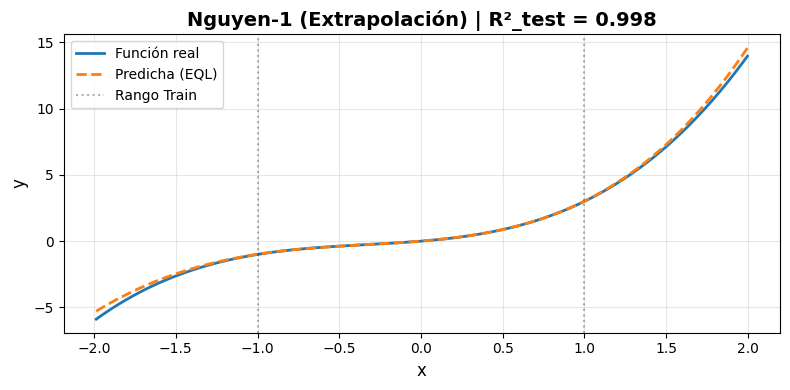


 PROCESANDO N2
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: (0.904*(0.05*x_1**2 + 0.136*x_1 + 0.294*sin(0.544*x_1**2) + 0.435)*(0.0952*x_1**2 + 0.261*x_1 + 0.275*sin(0.544*x_1**2) + 0.194) - 0.078)/(0.467*sin(0.016*x_1**2 + 0.044*x_1 - 0.211*sin(0.544*x_1**2) + 0.28) - 0.006)
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9999 | NRMSE: 0.0024
TEST  ((-2.0, 2.0)) -> R^2: 0.7249 | NRMSE: 0.1214
------------------------------


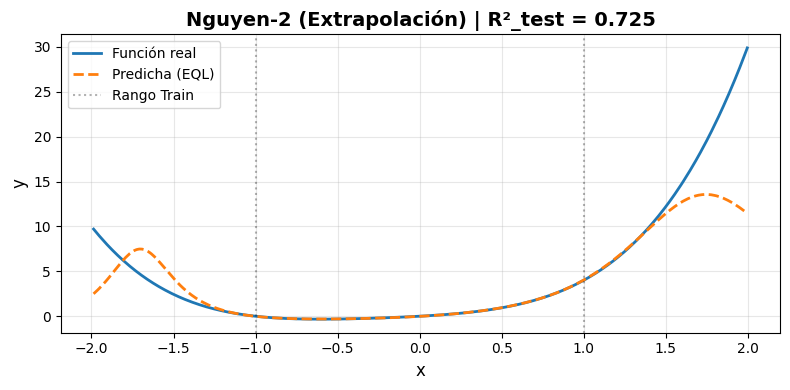


 PROCESANDO N3
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: -3.93*x_1*(0.428*x_1**2 + 0.357*x_1 + 0.191)/(sin(x_1*(0.0466*x_1**2 + 0.0389*x_1 + 0.0208)) - 1)
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9888 | NRMSE: 0.0236
TEST  ((-2.0, 2.0)) -> R^2: 0.8753 | NRMSE: 0.0648
------------------------------


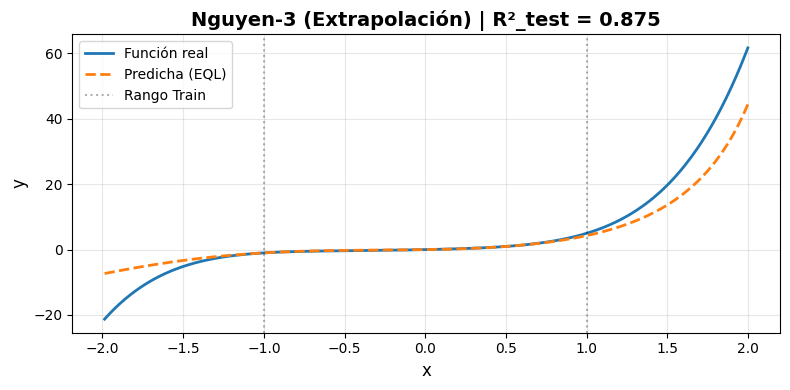


 PROCESANDO N4
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: (-0.211*sin(1.232*(0.759*x_1 - 1.163)*(0.802*x_1 + 0.25*sin(0.339*x_1 - 0.188) - 0.937)) + 0.286*cos(0.831*(0.759*x_1 - 1.163)*(0.802*x_1 + 0.25*sin(0.339*x_1 - 0.188) - 0.937) + 0.21) + 0.088)/(0.322*sin(1.232*(0.759*x_1 - 1.163)*(0.802*x_1 + 0.25*sin(0.339*x_1 - 0.188) - 0.937)) - 0.165*cos(0.831*(0.759*x_1 - 1.163)*(0.802*x_1 + 0.25*sin(0.339*x_1 - 0.188) - 0.937) + 0.21) + 0.204)
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9999 | NRMSE: 0.0021
TEST  ((-2.0, 2.0)) -> R^2: -0.1666 | NRMSE: 0.2226
------------------------------


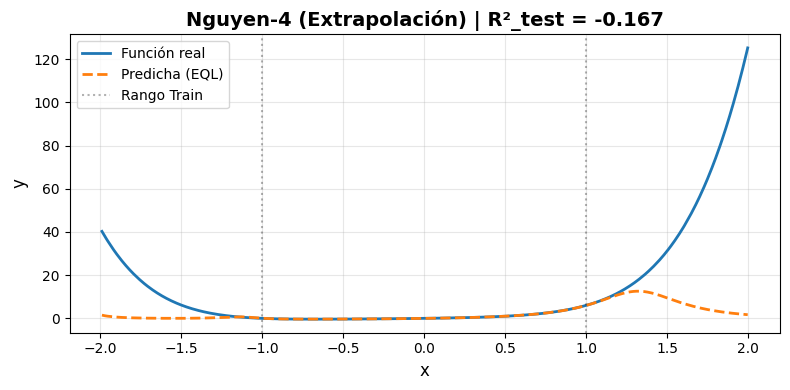


 PROCESANDO N5
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: 1.603 - 2.132/cos(1.094*sin(0.574*x_1**2 - 0.311) - 0.27)
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9941 | NRMSE: 0.0278
TEST  ((-2.0, 2.0)) -> R^2: -1.2008 | NRMSE: 0.4950
------------------------------


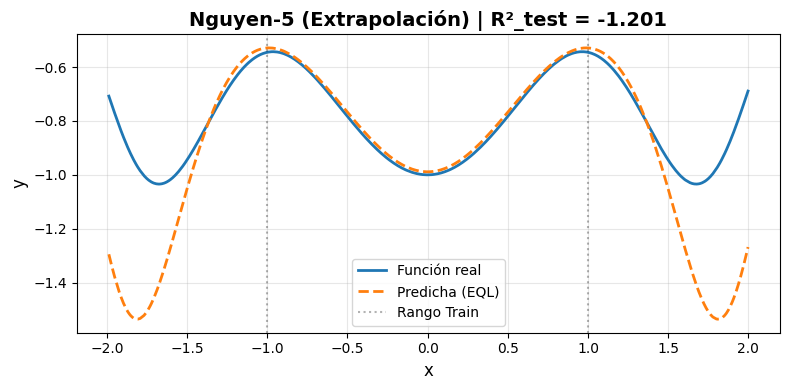


 PROCESANDO N6
--> Datos Generados. Dim: 1
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: -0.252*cos(0.658*x_1**2 - 1.29*x_1 + 1.58)/(0.129*cos(0.658*x_1**2 - 1.29*x_1 + 1.58) - 0.158)
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9998 | NRMSE: 0.0051
TEST  ((-2.0, 2.0)) -> R^2: -4.9878 | NRMSE: 0.7836
------------------------------


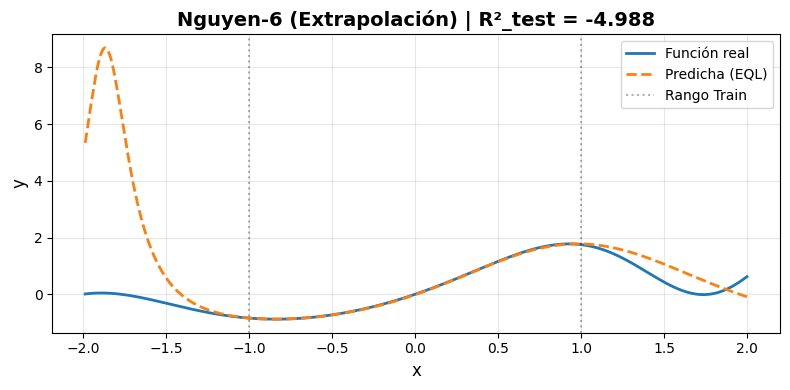


 PROCESANDO N7
--> Datos Generados. Dim: 1
    Train Rango: (0.1, 2.0)
    Test Rango:  (0.1, 6.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: (0.068*x_1**2 + 0.188*sin(0.391*x_1))/(0.012*x_1**2 + 0.035*sin(0.391*x_1) + 0.075)
------------------------------
TRAIN ((0.1, 2.0)) -> R^2: 0.9996 | NRMSE: 0.0064
TEST  ((0.1, 6.0)) -> R^2: 0.9677 | NRMSE: 0.0530
------------------------------


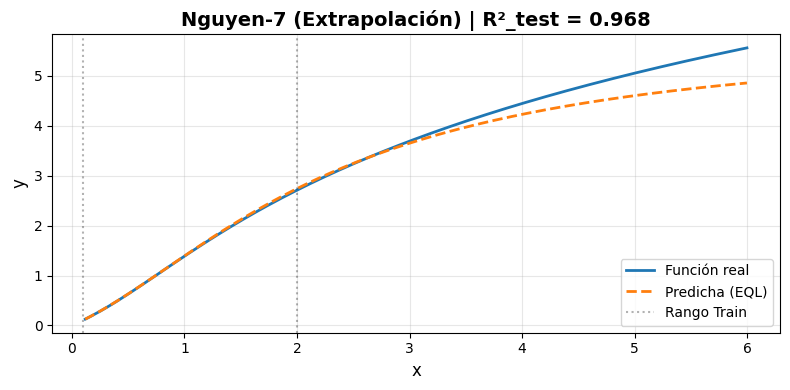


 PROCESANDO N8
--> Datos Generados. Dim: 1
    Train Rango: (0.1, 4.0)
    Test Rango:  (0.1, 6.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: 1.360
------------------------------
TRAIN ((0.1, 4.0)) -> R^2: -0.0010 | NRMSE: 0.2707
TEST  ((0.1, 6.0)) -> R^2: -0.3024 | NRMSE: 0.3030
------------------------------


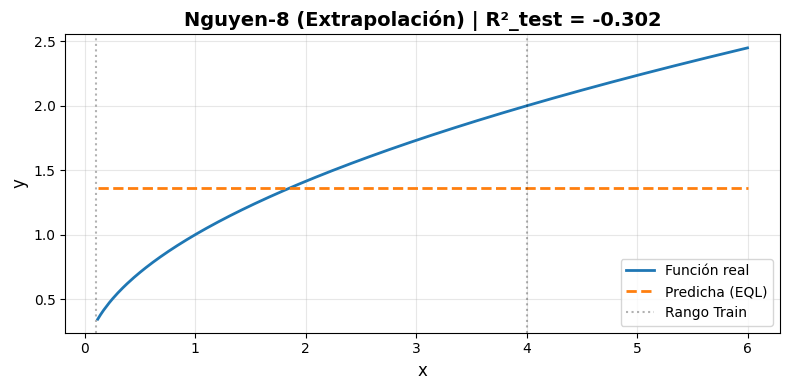


 PROCESANDO N9
--> Datos Generados. Dim: 2
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: 4.76*sin(0.189*x_2**2 + 0.213*sin(0.987*x_1)) + 0.003
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 0.9989 | NRMSE: 0.0078
TEST  ((-2.0, 2.0)) -> R^2: -1.3731 | NRMSE: 0.3757
------------------------------


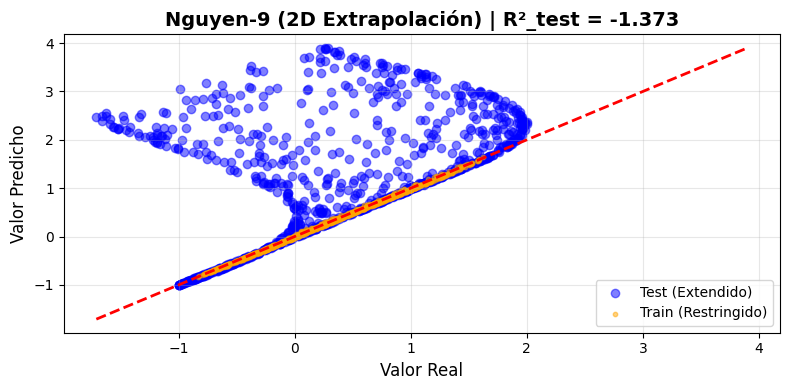


 PROCESANDO N10
--> Datos Generados. Dim: 2
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...


In [ ]:
import os
import shutil
import pickle
import gzip
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import Image, display

# --- RUTAS ---
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# --- SEMILLA ---
SEED = 42
np.random.seed(SEED)
try:
    tf.compat.v1.set_random_seed(SEED)
except:
    tf.set_random_seed(SEED)

# --- CONFIGURACIÓN ---
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "log", "div", "sqrt", "exp"] 

UNIVERSAL_CONFIG = {
    "num_h_layers": 3,      
    "layer_width": 1,       
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.001,     
    "epochs": 5000, 
    "generate_symbolic_expr": True,
    "train_val_split": 0.8, # Solo afecta al split interno de validación
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- GENERADOR DE DATOS (CON EXTRAPOLACIÓN) ---
def get_nguyen_xy(func_id, X):
    """Calcula Y dado X y el ID de función."""
    x = X[:, 0]
    dim = X.shape[1]
    if dim == 2: y_in = X[:, 1]

    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else: raise ValueError(f"ID {func_id} desconocido")
    
    return y.reshape(-1, 1).astype(np.float32)

def generate_extrapolated_data(func_id, n_train=1500, n_test=1000, seed=42):
    np.random.seed(seed)
    
    # 1. Definir Rangos de Entrenamiento (Restringidos) y Test (Extendidos)
    
    # Casos Positivos (Log, Sqrt) -> Train: [0, 2] o [0, 4] | Test: [0, 6]
    if func_id == 7: # Log
        # Train: [0.1, 2], Test: [0.1, 6]
        range_tr = (0.1, 2.0)
        range_te = (0.1, 6.0)
        dim = 1
    elif func_id == 8: # Sqrt
        # Train: [0.1, 4], Test: [0.1, 6]
        range_tr = (0.1, 4.0)
        range_te = (0.1, 6.0)
        dim = 1
    elif func_id == 11: # x^y
        # Train: [0.1, 2], Test: [0.1, 6] (Solo extendemos x para estabilidad)
        range_tr = (0.1, 2.0)
        range_te = (0.1, 6.0)
        dim = 2
        
    # Casos Estándar -> Train: [-1, 1] | Test: [-2, 2]
    elif func_id in [9, 10, 12]: # 2D
        range_tr = (-1.0, 1.0)
        range_te = (-2.0, 2.0)
        dim = 2
    else: # 1D (N1 - N6)
        range_tr = (-1.0, 1.0)
        range_te = (-2.0, 2.0)
        dim = 1

    # 2. Generar X
    # Train
    X_train = np.random.uniform(range_tr[0], range_tr[1], (n_train, dim))
    # Test (Muestreo uniforme en todo el rango extendido)
    X_test = np.random.uniform(range_te[0], range_te[1], (n_test, dim))

    # 3. Calcular Y
    y_train = get_nguyen_xy(func_id, X_train)
    y_test  = get_nguyen_xy(func_id, X_test)

    return X_train, y_train, X_test, y_test, dim, range_tr, range_te

# --- EVALUADOR ---
def evaluate_formula_from_text(formula_str, X_input):
    ns = {
        'sin': np.sin, 'cos': np.cos, 'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt, 
        'Pow': np.power, 'X': X_input
    }
    dim = X_input.shape[1]
    eval_str = formula_str
    for i in range(dim, 0, -1):
        eval_str = eval_str.replace(f"x_{i}", f"X[:,{i-1}]")
    
    try:
        y_pred = eval(eval_str, ns)
        if np.isscalar(y_pred) or np.ndim(y_pred) == 0:
            y_pred = np.full(X_input.shape[0], y_pred)
        return y_pred
    except Exception as e:
        return np.zeros(X_input.shape[0])

# --- EJECUCIÓN PRINCIPAL ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR: Ruta {EQL_PATH} no encontrada")
else:
    print(f"Iniciando Benchmark Nguyen (Extrapolación) en: {EQL_PATH}")
    
    for func_id in range(1, 13):
        RUN_ID = f"N{func_id}"
        print(f"\n{'='*40}")
        print(f" PROCESANDO {RUN_ID}")
        print(f"{'='*40}")
        
        # 1. Generar Datos (Extrapolados)
        try:
            n_tr_samp = 2000 if func_id in [11, 12] else 1000
            X_train, y_train, X_test, y_test, dim, r_tr, r_te = generate_extrapolated_data(
                func_id, n_train=n_tr_samp, n_test=1000, seed=SEED
            )
            print(f"--> Datos Generados. Dim: {dim}")
            print(f"    Train Rango: {r_tr}")
            print(f"    Test Rango:  {r_te} (Extrapolación)")
        except Exception as e:
            print(f"Error generando datos: {e}")
            continue

        # Guardar archivos
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        tf_train, tf_test = f"{RUN_ID}_train.pkl.gz", f"{RUN_ID}_test.pkl.gz"
        with gzip.open(os.path.join(data_dir, tf_train), "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(os.path.join(data_dir, tf_test), "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar y Limpiar
        curr_conf = UNIVERSAL_CONFIG.copy()
        curr_conf["id"] = RUN_ID 
        curr_conf["train_val_file"] = f"data/{tf_train}"
        curr_conf["test_file"] = f"data/{tf_test}"
        if "model_dir" in curr_conf: del curr_conf["model_dir"] 

        target_base_folder = os.path.join(EQL_PATH, "results", RUN_ID)
        if os.path.exists(target_base_folder): 
            try: shutil.rmtree(target_base_folder)
            except: pass

        # 3. Entrenar
        print(f"--> Entrenando...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print(f"--> Finalizado.")
            
            # 4. Recuperar y Evaluar
            found_txt = False
            if os.path.exists(target_base_folder):
                for root, dirs, files in os.walk(target_base_folder):
                    if "formula_y0.txt" in files:
                        txt_path = os.path.join(root, "formula_y0.txt")
                        png_path = os.path.join(root, "latex_y0.png")
                        
                        with open(txt_path, 'r') as f: formula_str = f.read().strip()
                        print(f"\n[FÓRMULA]: {formula_str}")
                        
                        # --- EVALUACIÓN Y MÉTRICAS ---
                        y_pred_train = evaluate_formula_from_text(formula_str, X_train)
                        y_pred_test  = evaluate_formula_from_text(formula_str, X_test)
                        
                        # Métricas Train (Rango corto)
                        r2_tr = r2_score(y_train, y_pred_train)
                        rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
                        range_tr_val = y_train.max() - y_train.min() if y_train.max() != y_train.min() else 1.0
                        nrmse_tr = rmse_tr / range_tr_val
                        
                        # Métricas Test (Rango extendido)
                        r2_te = r2_score(y_test, y_pred_test)
                        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))
                        range_te_val = y_test.max() - y_test.min() if y_test.max() != y_test.min() else 1.0
                        nrmse_te = rmse_te / range_te_val
                        
                        print("-" * 30)
                        print(f"TRAIN ({r_tr}) -> R^2: {r2_tr:.4f} | NRMSE: {nrmse_tr:.4f}")
                        print(f"TEST  ({r_te}) -> R^2: {r2_te:.4f} | NRMSE: {nrmse_te:.4f}")
                        print("-" * 30)
                        
                        # --- GRÁFICO (Estilo Solicitado) ---
                        if dim == 1:
                            # Ordenamos para dibujar línea
                            sort_idx = np.argsort(X_test[:, 0])
                            x = X_test[sort_idx, 0]
                            f_true = y_test[sort_idx]
                            f_pred = y_pred_test[sort_idx]
                            
                            plt.figure(figsize=(8,4))
                            plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
                            plt.plot(x, f_pred, '--', label="Predicha (EQL)", linewidth=2, color='C1')
                            
                            # Líneas verticales indicando rango de entrenamiento
                            plt.axvline(r_tr[0], color='k', linestyle=':', alpha=0.3)
                            plt.axvline(r_tr[1], color='k', linestyle=':', alpha=0.3, label='Rango Train')
                            
                            plt.xlabel("x", fontsize=12)
                            plt.ylabel("y", fontsize=12)
                            plt.title(f"Nguyen-{func_id} (Extrapolación) | R²_test = {r2_te:.3f}",
                                      fontsize=14, weight='bold')
                            plt.grid(True, alpha=0.3)
                            plt.legend()
                            plt.tight_layout()
                            plt.show()
                        else:
                            # 2D - Gráfico de contornos o paridad
                            plt.figure(figsize=(8,4))
                            # Usamos paridad para ver qué tan lejos se van los puntos en extrapolación
                            plt.scatter(y_test, y_pred_test, alpha=0.5, c='blue', label='Test (Extendido)')
                            plt.scatter(y_train, y_pred_train, alpha=0.5, c='orange', label='Train (Restringido)', s=10)
                            
                            # Línea ideal
                            min_val = min(y_test.min(), y_pred_test.min())
                            max_val = max(y_test.max(), y_pred_test.max())
                            plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
                            
                            plt.xlabel("Valor Real", fontsize=12)
                            plt.ylabel("Valor Predicho", fontsize=12)
                            plt.title(f"Nguyen-{func_id} (2D Extrapolación) | R²_test = {r2_te:.3f}",
                                      fontsize=14, weight='bold')
                            plt.legend()
                            plt.grid(True, alpha=0.3)
                            plt.tight_layout()
                            plt.show()

                        found_txt = True
                        break 
                if not found_txt: print("X - Fórmula no encontrada.")

        except subprocess.CalledProcessError as e:
            print(f"Error en entrenamiento {RUN_ID}.")

print("\nBENCHMARK FINALIZADO.")

Iniciando Benchmark Nguyen (Extrapolación) en: C:/Users/Benjamin/EQL_Tensorflow

 PROCESANDO N9
--> Datos Generados. Dim: 2
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: (0.427*(0.143*sin(0.932*x_2) + 0.864)*(0.859*(0.41*x_1 + 0.688*x_2)*(0.224*x_1 + 0.518*x_2 + 0.403) + 0.241*sin(0.932*x_2) - 0.059) + 0.057*(-x_1 + 0.33*x_2 + 0.711*sin(0.932*x_2) + 0.169)**2*(0.0256*x_1**2 + 0.103*x_1*x_2 + 0.333*x_1 + 0.1*x_2**2 + 0.0968*x_2 + 0.353*sin(0.932*x_2) - 1.0)**2 + 0.343*(-0.833*x_1 + 0.275*x_2 + 0.592*sin(0.932*x_2) + 0.141)*(0.0178*x_1**2 + 0.0714*x_1*x_2 + 0.235*x_1 + 0.069*x_2**2 + 0.0667*x_2 + 0.25*sin(0.932*x_2) - 0.7) + 0.053)/(0.064*(0.143*sin(0.932*x_2) + 0.864)*(0.859*(0.41*x_1 + 0.688*x_2)*(0.224*x_1 + 0.518*x_2 + 0.403) + 0.241*sin(0.932*x_2) - 0.059) + 0.052*(-0.833*x_1 + 0.275*x_2 + 0.592*sin(0.932*x_2) + 0.141)*(0.0178*x_1**2 + 0.0714*x_1*x_2 + 0.235*x_1 + 0.069*x_2**2 + 0.0667*x_2 + 0.25*sin(0.932*x_2

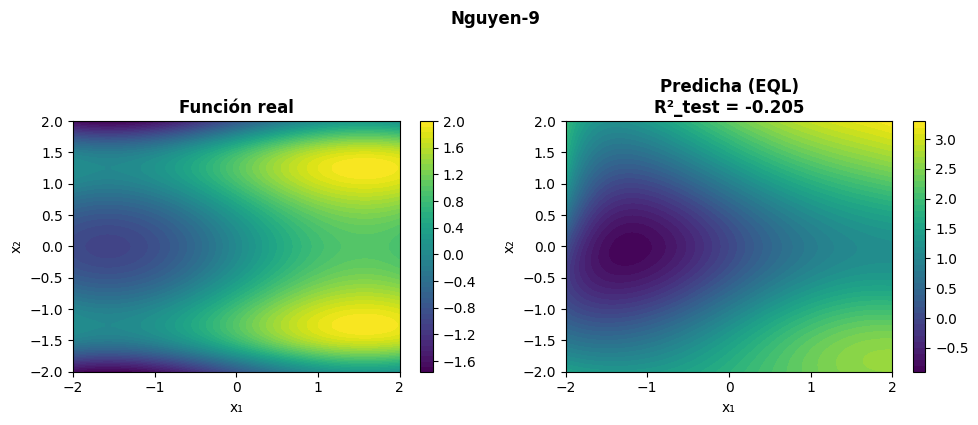


 PROCESANDO N10
--> Datos Generados. Dim: 2
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
--> Finalizado.

[FÓRMULA]: 0.08*(0.811 - 0.005*x_2**2)*(0.389*sin(0.904*x_1 - 1.019*x_2) + 0.932*sin(0.906*x_1 + 1.007*x_2) - 0.221) + 3.254*sin(0.431*(0.811 - 0.005*x_2**2)*(0.389*sin(0.904*x_1 - 1.019*x_2) + 0.932*sin(0.906*x_1 + 1.007*x_2) - 0.221) + 0.196*sin(0.904*x_1 - 1.019*x_2) + 0.076) + 0.018
------------------------------
TRAIN ((-1.0, 1.0)) -> R^2: 1.0000
TEST  ((-2.0, 2.0)) -> R^2: 0.9970 | NRMSE: 0.0138
------------------------------


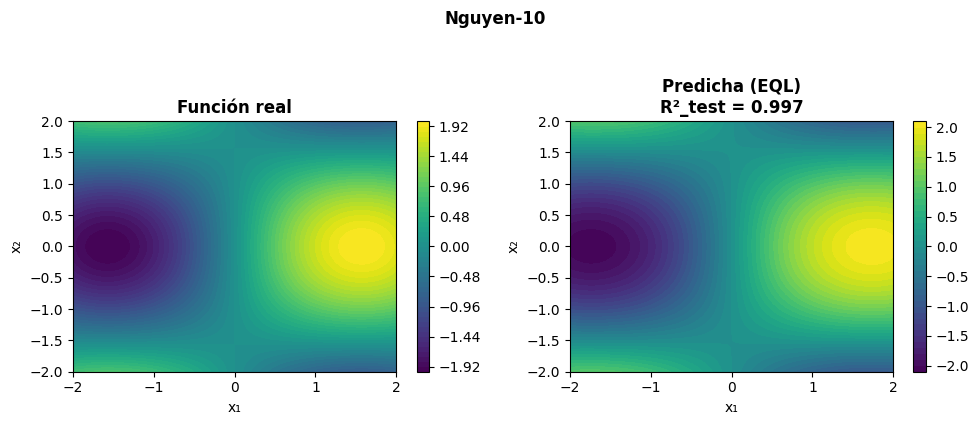


 PROCESANDO N11
--> Datos Generados. Dim: 2
    Train Rango: (0.1, 2.0)
    Test Rango:  (0.1, 6.0) (Extrapolación)
--> Entrenando...
Error en entrenamiento N11.

 PROCESANDO N12
--> Datos Generados. Dim: 2
    Train Rango: (-1.0, 1.0)
    Test Rango:  (-2.0, 2.0) (Extrapolación)
--> Entrenando...
Error en entrenamiento N12.

BENCHMARK FINALIZADO.


In [1]:
import os
import shutil
import pickle
import gzip
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import r2_score, mean_squared_error

# --- RUTAS ---
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# --- SEMILLA ---
SEED = 42
np.random.seed(SEED)
try:
    tf.compat.v1.set_random_seed(SEED)
except:
    tf.set_random_seed(SEED)

# --- CONFIGURACIÓN ---
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "log", "div", "sqrt", "exp"] 

UNIVERSAL_CONFIG = {
    "num_h_layers": 3,      
    "layer_width": 2,       
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.0001,     
    "epochs": 5000, 
    "generate_symbolic_expr": True,
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- GENERADOR DE DATOS ---
def get_nguyen_xy(func_id, X):
    x = X[:, 0]
    dim = X.shape[1]
    if dim == 2: y_in = X[:, 1]

    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else: raise ValueError(f"ID {func_id} desconocido")
    
    return y.reshape(-1, 1).astype(np.float32)

def generate_extrapolated_data(func_id, n_train=1500, n_test=1000, seed=42):
    np.random.seed(seed)
    
    if func_id == 7: # Log
        range_tr = (0.1, 2.0); range_te = (0.1, 6.0); dim = 1
    elif func_id == 8: # Sqrt
        range_tr = (0.1, 4.0); range_te = (0.1, 6.0); dim = 1
    elif func_id == 11: # x^y
        range_tr = (0.1, 2.0); range_te = (0.1, 6.0); dim = 2
    elif func_id in [9, 10, 12]: # 2D
        range_tr = (-1.0, 1.0); range_te = (-2.0, 2.0); dim = 2
    else: # 1D (N1 - N6)
        range_tr = (-1.0, 1.0); range_te = (-2.0, 2.0); dim = 1

    X_train = np.random.uniform(range_tr[0], range_tr[1], (n_train, dim))
    X_test = np.random.uniform(range_te[0], range_te[1], (n_test, dim))

    y_train = get_nguyen_xy(func_id, X_train)
    y_test  = get_nguyen_xy(func_id, X_test)

    return X_train, y_train, X_test, y_test, dim, range_tr, range_te

# --- EVALUADOR ---
def evaluate_formula_from_text(formula_str, X_input):
    ns = {
        'sin': np.sin, 'cos': np.cos, 'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt, 
        'Pow': np.power, 'X': X_input
    }
    dim = X_input.shape[1]
    eval_str = formula_str
    for i in range(dim, 0, -1):
        eval_str = eval_str.replace(f"x_{i}", f"X[:,{i-1}]")
    
    try:
        y_pred = eval(eval_str, ns)
        if np.isscalar(y_pred) or np.ndim(y_pred) == 0:
            y_pred = np.full(X_input.shape[0], y_pred)
        return y_pred
    except Exception as e:
        return np.zeros(X_input.shape[0])

# --- EJECUCIÓN PRINCIPAL ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR: Ruta {EQL_PATH} no encontrada")
else:
    print(f"Iniciando Benchmark Nguyen (Extrapolación) en: {EQL_PATH}")
    
    for func_id in range(9, 13):
        # Limpieza de variables críticas al inicio del bucle para evitar contaminación
        if 'f_pred' in locals(): del f_pred
        
        RUN_ID = f"N{func_id}"
        print(f"\n{'='*40}")
        print(f" PROCESANDO {RUN_ID}")
        print(f"{'='*40}")
        
        # 1. Generar Datos
        try:
            n_tr_samp = 2000 if func_id in [11, 12] else 1000
            X_train, y_train, X_test, y_test, dim, r_tr, r_te = generate_extrapolated_data(
                func_id, n_train=n_tr_samp, n_test=1000, seed=SEED
            )
            print(f"--> Datos Generados. Dim: {dim}")
            print(f"    Train Rango: {r_tr}")
            print(f"    Test Rango:  {r_te} (Extrapolación)")
        except Exception as e:
            print(f"Error generando datos: {e}")
            continue

        # Guardar archivos
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        tf_train, tf_test = f"{RUN_ID}_train.pkl.gz", f"{RUN_ID}_test.pkl.gz"
        with gzip.open(os.path.join(data_dir, tf_train), "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(os.path.join(data_dir, tf_test), "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar
        curr_conf = UNIVERSAL_CONFIG.copy()
        curr_conf["id"] = RUN_ID 
        curr_conf["train_val_file"] = f"data/{tf_train}"
        curr_conf["test_file"] = f"data/{tf_test}"
        if "model_dir" in curr_conf: del curr_conf["model_dir"] 

        target_base_folder = os.path.join(EQL_PATH, "results", RUN_ID)
        if os.path.exists(target_base_folder): 
            try: shutil.rmtree(target_base_folder)
            except: pass

        # 3. Entrenar
        print(f"--> Entrenando...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print(f"--> Finalizado.")
            
            # 4. Recuperar y Evaluar
            found_txt = False
            if os.path.exists(target_base_folder):
                for root, dirs, files in os.walk(target_base_folder):
                    if "formula_y0.txt" in files:
                        txt_path = os.path.join(root, "formula_y0.txt")
                        
                        with open(txt_path, 'r') as f: formula_str = f.read().strip()
                        print(f"\n[FÓRMULA]: {formula_str}")
                        
                        y_pred_train = evaluate_formula_from_text(formula_str, X_train)
                        y_pred_test  = evaluate_formula_from_text(formula_str, X_test)
                        
                        r2_tr = r2_score(y_train, y_pred_train)
                        r2_te = r2_score(y_test, y_pred_test)
                        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))
                        range_te_val = y_test.max() - y_test.min() if y_test.max() != y_test.min() else 1.0
                        nrmse_te = rmse_te / range_te_val
                        
                        print("-" * 30)
                        print(f"TRAIN ({r_tr}) -> R^2: {r2_tr:.4f}")
                        print(f"TEST  ({r_te}) -> R^2: {r2_te:.4f} | NRMSE: {nrmse_te:.4f}")
                        print("-" * 30)
                        
                        # --- GRÁFICO ---
                        if dim == 1:
                            # 1D PLOT
                            sort_idx = np.argsort(X_test[:, 0])
                            x = X_test[sort_idx, 0]
                            f_true = y_test[sort_idx]
                            # Aquí asignamos f_pred para uso local en 1D
                            f_pred = y_pred_test[sort_idx]
                            
                            plt.figure(figsize=(8,4))
                            plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
                            plt.plot(x, f_pred, '--', label="Predicha (EQL)", linewidth=2, color='C1')
                            plt.axvline(r_tr[0], color='k', linestyle=':', alpha=0.3)
                            plt.axvline(r_tr[1], color='k', linestyle=':', alpha=0.3, label='Rango Train')
                            plt.xlabel("x"); plt.ylabel("y")
                            plt.title(f"Nguyen-{func_id} (Extrapolación) | R²_test = {r2_te:.3f}", weight='bold')
                            plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
                            plt.show()
                        else:
                            # 2D PLOT (CORREGIDO)
                            grid_res = 100
                            x_grid = np.linspace(r_te[0], r_te[1], grid_res)
                            X1, X2 = np.meshgrid(x_grid, x_grid)
                            X_flat = np.column_stack([X1.ravel(), X2.ravel()])
                            
                            f_true_flat = get_nguyen_xy(func_id, X_flat)
                            f_true_2d = f_true_flat.reshape(X1.shape)
                            
                            f_pred_flat = evaluate_formula_from_text(formula_str, X_flat)
                            
                            # CORRECCIÓN AQUÍ: Asignación directa sin chequear locals()
                            f_pred_2d = f_pred_flat.reshape(X1.shape)

                            fig, axs = plt.subplots(1, 2, figsize=(10,4))
                            cs0 = axs[0].contourf(X1, X2, f_true_2d, levels=50, cmap='viridis')
                            axs[0].set_title("Función real", weight='bold')
                            fig.colorbar(cs0, ax=axs[0])
                            
                            cs1 = axs[1].contourf(X1, X2, f_pred_2d, levels=50, cmap='viridis')
                            axs[1].set_title(f"Predicha (EQL)\nR²_test = {r2_te:.3f}", weight='bold')
                            fig.colorbar(cs1, ax=axs[1])
                            
                            for ax in axs: ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
                            plt.suptitle(f"Nguyen-{func_id}", y=1.05, weight='bold')
                            plt.tight_layout(); plt.show()

                        found_txt = True
                        break 
                if not found_txt: print("X - Fórmula no encontrada.")

        except subprocess.CalledProcessError as e:
            print(f"Error en entrenamiento {RUN_ID}.")

print("\nBENCHMARK FINALIZADO.")

In [ ]:
import os
import shutil
import pickle
import gzip
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import r2_score, mean_squared_error

# --- RUTAS ---
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# --- SEMILLA ---
SEED = 42
np.random.seed(SEED)
try:
    tf.compat.v1.set_random_seed(SEED)
except:
    tf.set_random_seed(SEED)

# --- CONFIGURACIÓN ---
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "log", "div", "sqrt", "exp"] 

UNIVERSAL_CONFIG = {
    "num_h_layers": 3,      
    "layer_width": 2,       
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.0001,     
    "epochs": 8000, 
    "generate_symbolic_expr": True,
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- GENERADOR DE DATOS ---
def get_nguyen_xy(func_id, X):
    x = X[:, 0]
    dim = X.shape[1]
    if dim == 2: y_in = X[:, 1]

    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else: raise ValueError(f"ID {func_id} desconocido")
    
    return y.reshape(-1, 1).astype(np.float32)

def generate_extrapolated_data(func_id, n_train=1500, n_test=1000, seed=42):
    np.random.seed(seed)
    
    if func_id == 7: # Log
        range_tr = (0.1, 2.0); range_te = (0.1, 4.0); dim = 1
    elif func_id == 8: # Sqrt
        range_tr = (0.1, 4.0); range_te = (0.1, 6.0); dim = 1
    elif func_id == 11: # x^y
        range_tr = (0.1, 2.0); range_te = (0.1, 4.0); dim = 2
    elif func_id in [9, 10, 12]: # 2D
        range_tr = (-1.0, 1.0); range_te = (-2.0, 2.0); dim = 2
    else: # 1D (N1 - N6)
        range_tr = (-1.0, 1.0); range_te = (-2.0, 2.0); dim = 1

    X_train = np.random.uniform(range_tr[0], range_tr[1], (n_train, dim))
    X_test = np.random.uniform(range_te[0], range_te[1], (n_test, dim))

    y_train = get_nguyen_xy(func_id, X_train)
    y_test  = get_nguyen_xy(func_id, X_test)

    return X_train, y_train, X_test, y_test, dim, range_tr, range_te

# --- EVALUADOR ---
def evaluate_formula_from_text(formula_str, X_input):
    ns = {
        'sin': np.sin, 'cos': np.cos, 'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt, 
        'Pow': np.power, 'X': X_input
    }
    dim = X_input.shape[1]
    eval_str = formula_str
    for i in range(dim, 0, -1):
        eval_str = eval_str.replace(f"x_{i}", f"X[:,{i-1}]")
    
    try:
        y_pred = eval(eval_str, ns)
        if np.isscalar(y_pred) or np.ndim(y_pred) == 0:
            y_pred = np.full(X_input.shape[0], y_pred)
        return y_pred
    except Exception as e:
        return np.zeros(X_input.shape[0])

# --- EJECUCIÓN PRINCIPAL ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR: Ruta {EQL_PATH} no encontrada")
else:
    print(f"Iniciando Benchmark Nguyen (Extrapolación) en: {EQL_PATH}")
    
    for func_id in [11]:
        # Limpieza de variables críticas al inicio del bucle para evitar contaminación
        if 'f_pred' in locals(): del f_pred
        
        RUN_ID = f"N{func_id}"
        print(f"\n{'='*40}")
        print(f" PROCESANDO {RUN_ID}")
        print(f"{'='*40}")
        
        # 1. Generar Datos
        try:
            n_tr_samp = 2000 if func_id in [11, 12] else 1000
            X_train, y_train, X_test, y_test, dim, r_tr, r_te = generate_extrapolated_data(
                func_id, n_train=n_tr_samp, n_test=1000, seed=SEED
            )
            print(f"--> Datos Generados. Dim: {dim}")
            print(f"    Train Rango: {r_tr}")
            print(f"    Test Rango:  {r_te} (Extrapolación)")
        except Exception as e:
            print(f"Error generando datos: {e}")
            continue

        # Guardar archivos
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        tf_train, tf_test = f"{RUN_ID}_train.pkl.gz", f"{RUN_ID}_test.pkl.gz"
        with gzip.open(os.path.join(data_dir, tf_train), "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(os.path.join(data_dir, tf_test), "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar
        curr_conf = UNIVERSAL_CONFIG.copy()
        curr_conf["id"] = RUN_ID 
        curr_conf["train_val_file"] = f"data/{tf_train}"
        curr_conf["test_file"] = f"data/{tf_test}"
        if "model_dir" in curr_conf: del curr_conf["model_dir"] 

        target_base_folder = os.path.join(EQL_PATH, "results", RUN_ID)
        if os.path.exists(target_base_folder): 
            try: shutil.rmtree(target_base_folder)
            except: pass

        # 3. Entrenar
        print(f"--> Entrenando...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print(f"--> Finalizado.")
            
            # 4. Recuperar y Evaluar
            found_txt = False
            if os.path.exists(target_base_folder):
                for root, dirs, files in os.walk(target_base_folder):
                    if "formula_y0.txt" in files:
                        txt_path = os.path.join(root, "formula_y0.txt")
                        
                        with open(txt_path, 'r') as f: formula_str = f.read().strip()
                        print(f"\n[FÓRMULA]: {formula_str}")
                        
                        y_pred_train = evaluate_formula_from_text(formula_str, X_train)
                        y_pred_test  = evaluate_formula_from_text(formula_str, X_test)
                        
                        r2_tr = r2_score(y_train, y_pred_train)
                        r2_te = r2_score(y_test, y_pred_test)
                        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))
                        range_te_val = y_test.max() - y_test.min() if y_test.max() != y_test.min() else 1.0
                        nrmse_te = rmse_te / range_te_val
                        
                        print("-" * 30)
                        print(f"TRAIN ({r_tr}) -> R^2: {r2_tr:.4f}")
                        print(f"TEST  ({r_te}) -> R^2: {r2_te:.4f} | NRMSE: {nrmse_te:.4f}")
                        print("-" * 30)
                        
                        # --- GRÁFICO ---
                        if dim == 1:
                            # 1D PLOT
                            sort_idx = np.argsort(X_test[:, 0])
                            x = X_test[sort_idx, 0]
                            f_true = y_test[sort_idx]
                            # Aquí asignamos f_pred para uso local en 1D
                            f_pred = y_pred_test[sort_idx]
                            
                            plt.figure(figsize=(8,4))
                            plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
                            plt.plot(x, f_pred, '--', label="Predicha (EQL)", linewidth=2, color='C1')
                            plt.axvline(r_tr[0], color='k', linestyle=':', alpha=0.3)
                            plt.axvline(r_tr[1], color='k', linestyle=':', alpha=0.3, label='Rango Train')
                            plt.xlabel("x"); plt.ylabel("y")
                            plt.title(f"Nguyen-{func_id} (Extrapolación) | R²_test = {r2_te:.3f}", weight='bold')
                            plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
                            plt.show()
                        else:
                            # 2D PLOT (CORREGIDO)
                            grid_res = 100
                            x_grid = np.linspace(r_te[0], r_te[1], grid_res)
                            X1, X2 = np.meshgrid(x_grid, x_grid)
                            X_flat = np.column_stack([X1.ravel(), X2.ravel()])
                            
                            f_true_flat = get_nguyen_xy(func_id, X_flat)
                            f_true_2d = f_true_flat.reshape(X1.shape)
                            
                            f_pred_flat = evaluate_formula_from_text(formula_str, X_flat)
                            
                            # CORRECCIÓN AQUÍ: Asignación directa sin chequear locals()
                            f_pred_2d = f_pred_flat.reshape(X1.shape)

                            fig, axs = plt.subplots(1, 2, figsize=(10,4))
                            cs0 = axs[0].contourf(X1, X2, f_true_2d, levels=50, cmap='viridis')
                            axs[0].set_title("Función real", weight='bold')
                            fig.colorbar(cs0, ax=axs[0])
                            
                            cs1 = axs[1].contourf(X1, X2, f_pred_2d, levels=50, cmap='viridis')
                            axs[1].set_title(f"Predicha (EQL)\nR²_test = {r2_te:.3f}", weight='bold')
                            fig.colorbar(cs1, ax=axs[1])
                            
                            for ax in axs: ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
                            plt.suptitle(f"Nguyen-{func_id}", y=1.05, weight='bold')
                            plt.tight_layout(); plt.show()

                        found_txt = True
                        break 
                if not found_txt: print("X - Fórmula no encontrada.")

        except subprocess.CalledProcessError as e:
            print(f"Error en entrenamiento {RUN_ID}.")

print("\nBENCHMARK FINALIZADO.")

Iniciando Benchmark Nguyen (Extrapolación) en: C:/Users/Benjamin/EQL_Tensorflow

 PROCESANDO N11
--> Datos Generados. Dim: 2
    Train Rango: (0.1, 2.0)
    Test Rango:  (0.1, 4.0) (Extrapolación)
--> Entrenando...


--> Iniciando proceso para DATOS DE BATERÍAS
--> Archivo cargado.
--> Datos procesados: 3690 muestras. Inputs: 3
--> Ejecutando train.py...
--> Entrenamiento finalizado.

[FÓRMULA]: (0.14*x_1 + 0.007*x_3**2*(0.643*x_1 - 0.27*x_3 + 1)**2 - 0.029*x_3*(0.313*x_1 - 0.132*x_3 + 0.487))/(0.015*x_1 + 0.001*x_3**2*(0.643*x_1 - 0.27*x_3 + 1)**2 - 0.003*x_3*(0.313*x_1 - 0.132*x_3 + 0.487) + 0.131)


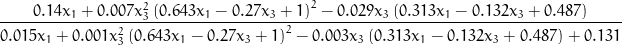

------------------------------
TRAIN -> R^2: 0.9889 | NRMSE: 0.0188
TEST  -> R^2: 0.9896 | NRMSE: 0.0179
------------------------------


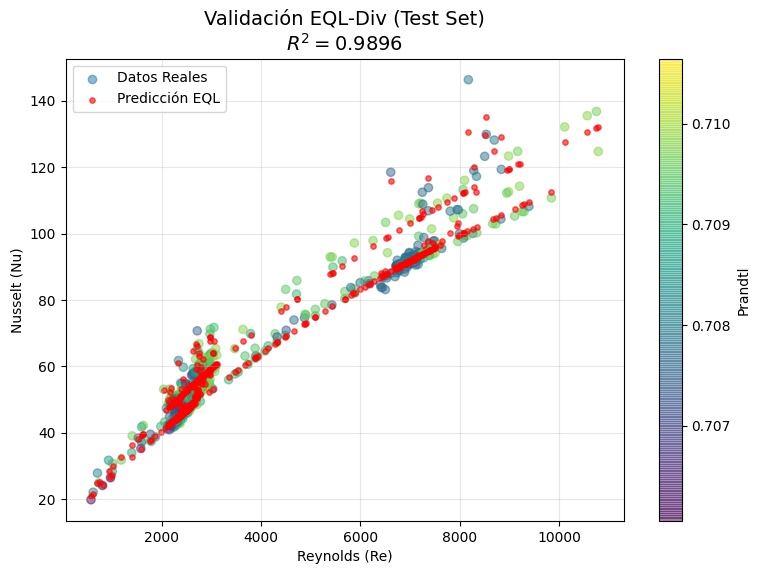


PROCESO TERMINADO.


In [3]:
import os
import shutil
import pickle
import gzip
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import Image, display

# --- 1. CONFIGURACIÓN ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 
DATA_FILE = "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"

# Configuración EQL-Div
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "div", "log", "sqrt", "exp"]

BATTERY_CONFIG = {
    "id": "Battery_Nu",    
    "num_h_layers": 3,     # Capas (ajustable si falta potencia, sube a 2)
    "layer_width": 1,      # Ancho (ajustable si falta potencia, sube a 4)
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.001,    
    "epochs": 5000,        
    "generate_symbolic_expr": True,
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- 2. FUNCIÓN AUXILIAR PARA EVALUAR STRING ---
def evaluate_formula_from_text(formula_str, X_input):
    """
    Evalúa la fórmula string reemplazando x_1 por X[:,0], etc.
    """
    # Contexto matemático seguro
    ns = {
        'sin': np.sin, 'cos': np.cos, 'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt, 
        'Pow': np.power, 'X': X_input
    }
    
    # Reemplazo de variables (x_1 -> X[:,0])
    dim = X_input.shape[1]
    eval_str = formula_str
    for i in range(dim, 0, -1):
        eval_str = eval_str.replace(f"x_{i}", f"X[:,{i-1}]")
    
    try:
        y_pred = eval(eval_str, ns)
        if np.isscalar(y_pred) or np.ndim(y_pred) == 0:
            y_pred = np.full(X_input.shape[0], y_pred)
        return y_pred
    except Exception as e:
        print(f"Error evaluando fórmula: {e}")
        return np.zeros(X_input.shape[0])

# --- 3. PROCESO PRINCIPAL ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR CRÍTICO: No se encuentra {EQL_PATH}")
else:
    print(f"--> Iniciando proceso para DATOS DE BATERÍAS")
    
    # A) Cargar y Limpiar
    try:
        if os.path.exists(DATA_FILE):
            df = pd.read_csv(DATA_FILE)
        else:
            df = pd.read_csv("df_n_25.txt") # Fallback local
            
        print("--> Archivo cargado.")
        
        # Limpieza
        df = df.dropna()
        mask = (df['Rem'] > 0) & (df['prandtl'] > 0) & (df['nusselt'] > 0)
        df_clean = df[mask].copy()
        
        inputs = ['Rem', 'prandtl', 'K']
        output = 'nusselt'
        
        X_raw = df_clean[inputs].values.astype(np.float32)
        y_raw = df_clean[output].values.reshape(-1, 1).astype(np.float32)
        
        # B) Normalización (Guardamos stats para desnormalizar gráficos después)
        X_mean, X_std = X_raw.mean(0), X_raw.std(0) + 1e-6
        y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-6
        
        X_norm = (X_raw - X_mean) / X_std
        y_norm = (y_raw - y_mean) / y_std
        
        print(f"--> Datos procesados: {X_norm.shape[0]} muestras. Inputs: 3")

        # C) Split y Guardado
        X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=SEED)

        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        
        file_name_base = "battery_data"
        path_train = os.path.join(data_dir, f"{file_name_base}_train.pkl.gz")
        path_test = os.path.join(data_dir, f"{file_name_base}_test.pkl.gz")
        
        with gzip.open(path_train, "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(path_test, "wb") as f: pickle.dump((X_test, y_test), f)
            
        # D) Entrenamiento
        unique_dir = "results/Battery_Nu"
        full_result_path = os.path.join(EQL_PATH, unique_dir)
        if os.path.exists(full_result_path): shutil.rmtree(full_result_path)

        curr_conf = BATTERY_CONFIG.copy()
        curr_conf["train_val_file"] = f"data/{file_name_base}_train.pkl.gz"
        curr_conf["test_file"]      = f"data/{file_name_base}_test.pkl.gz"
        curr_conf["model_dir"]      = unique_dir

        print(f"--> Ejecutando train.py...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print("--> Entrenamiento finalizado.")
            
            # E) Recuperación y Evaluación
            # Buscamos la fórmula dentro de la carpeta generada
            found_txt = False
            if os.path.exists(full_result_path):
                for root, dirs, files in os.walk(full_result_path):
                    if "formula_y0.txt" in files:
                        txt_path = os.path.join(root, "formula_y0.txt")
                        png_path = os.path.join(root, "latex_y0.png")
                        
                        with open(txt_path, 'r') as f:
                            formula_str = f.read().strip()
                        
                        print(f"\n[FÓRMULA]: {formula_str}")
                        if os.path.exists(png_path): display(Image(filename=png_path))
                        
                        # --- EVALUACIÓN NUMÉRICA ---
                        # Predecimos valores NORMALIZADOS usando la fórmula
                        y_pred_train_norm = evaluate_formula_from_text(formula_str, X_train)
                        y_pred_test_norm  = evaluate_formula_from_text(formula_str, X_test)
                        
                        # --- DESNORMALIZACIÓN ---
                        # Llevamos todo a la escala real para calcular métricas físicas
                        y_train_real = y_train.flatten() * y_std + y_mean
                        y_pred_train_real = y_pred_train_norm * y_std + y_mean
                        
                        y_test_real = y_test.flatten() * y_std + y_mean
                        y_pred_test_real = y_pred_test_norm * y_std + y_mean
                        
                        # --- MÉTRICAS ---
                        # Train
                        r2_tr = r2_score(y_train_real, y_pred_train_real)
                        rmse_tr = np.sqrt(mean_squared_error(y_train_real, y_pred_train_real))
                        nrmse_tr = rmse_tr / (y_train_real.max() - y_train_real.min())
                        
                        # Test
                        r2_te = r2_score(y_test_real, y_pred_test_real)
                        rmse_te = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
                        nrmse_te = rmse_te / (y_test_real.max() - y_test_real.min())
                        
                        print("-" * 30)
                        print(f"TRAIN -> R^2: {r2_tr:.4f} | NRMSE: {nrmse_tr:.4f}")
                        print(f"TEST  -> R^2: {r2_te:.4f} | NRMSE: {nrmse_te:.4f}")
                        print("-" * 30)
                        
                        # --- GRÁFICO (Solo Test) ---
                        # Desnormalizamos X_test para graficar Reynolds real
                        X_test_real = X_test * X_std + X_mean
                        Re_test_real = X_test_real[:, 0]
                        Pr_test_real = X_test_real[:, 1] # Para el color
                        
                        plt.figure(figsize=(9, 6))
                        
                        # Datos Reales
                        sc = plt.scatter(Re_test_real, y_test_real, c=Pr_test_real, cmap='viridis', 
                                         alpha=0.5, label='Datos Reales')
                        
                        # Predicción EQL
                        plt.scatter(Re_test_real, y_pred_test_real, color='red', s=15, alpha=0.6, label='Predicción EQL')
                        
                        plt.colorbar(sc, label='Prandtl')
                        plt.xlabel('Reynolds (Re)')
                        plt.ylabel('Nusselt (Nu)')
                        plt.title(f'Validación EQL-Div (Test Set)\n$R^2 = {r2_te:.4f}$', fontsize=14)
                        plt.legend()
                        plt.grid(True, alpha=0.3)
                        plt.show()
                        
                        found_txt = True
                        break 
                
                if not found_txt:
                    print("X - No se encontró 'formula_y0.txt'.")
            else:
                print("X - No se creó la carpeta de resultados.")

        except subprocess.CalledProcessError as e:
            print(f"ERROR en subprocess.")
            if e.stderr: print('\n'.join(e.stderr.split('\n')[-5:]))

    except Exception as e:
        print(f"Error general: {e}")

print("\nPROCESO TERMINADO.")

--> Iniciando proceso para DATOS DE BATERÍAS
--> Archivo cargado correctamente.
--> Datos procesados: 3690 muestras. Inputs: 3
--> Archivos guardados en: C:/Users/Benjamin/EQL_Tensorflow\data
--> Ejecutando train.py vía subprocess...
--> Entrenamiento finalizado con éxito.

--- FÓRMULA DESCUBIERTA (BATERÍAS) ---
Mostrando fórmula LaTeX renderizada:


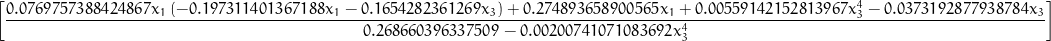


PROCESO TERMINADO.


In [4]:
import os
import shutil
import pickle
import gzip
import subprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

# --- 1. CONFIGURACIÓN DE RUTAS Y PARÁMETROS ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 
DATA_FILE = "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"

# Importante: Agregamos "div" para EQL-Div y "id" para pasar variables limpias
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "div"]

# Configuración ajustada para física (Baterías)
BATTERY_CONFIG = {
    "id": "Battery_Nu",    # Nombre del experimento
    "num_h_layers": 2,     # 2 capas suele ser mejor para fórmulas físicas cortas
    "layer_width": 4,      # 4 neuronas para dar "ancho" a las 3 variables de entrada
    "batch_size": 32,
    "learning_rate": 0.001, # Un poco más suave que 0.005 para no divergir
    "reg_scale": 0.001,    # Lambda bajo (1e-3) para permitir constantes físicas
    "epochs": 5000,        # Suficientes épocas
    "generate_symbolic_expr": True,
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- 2. CARGA Y PREPARACIÓN DE DATOS ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR CRÍTICO: No se encuentra la carpeta del repositorio en {EQL_PATH}")
else:
    print(f"--> Iniciando proceso para DATOS DE BATERÍAS")
    
    # A) Cargar DataFrame
    try:
        # Intentamos cargar con la ruta completa, si falla buscamos local
        if os.path.exists(DATA_FILE):
            df = pd.read_csv(DATA_FILE)
        else:
            # Fallback: intentar leer localmente si subiste el archivo al entorno
            df = pd.read_csv("df_n_25.txt")
        
        print("--> Archivo cargado correctamente.")
        
        # B) Limpieza Física (Evitar log/div por cero)
        df = df.dropna()
        mask = (df['Rem'] > 0) & (df['prandtl'] > 0) & (df['nusselt'] > 0)
        df_clean = df[mask].copy()
        
        # C) Definir X (Inputs) e y (Output)
        # Orden: x0=Re, x1=Pr, x2=K
        inputs = ['Rem', 'prandtl', 'K']
        output = 'nusselt'
        
        X_raw = df_clean[inputs].values.astype(np.float32)
        y_raw = df_clean[output].values.reshape(-1, 1).astype(np.float32)
        
        # D) Normalización (OBLIGATORIA para EQL)
        # Guardamos estadísticas para desnormalizar después si es necesario
        X_mean, X_std = X_raw.mean(0), X_raw.std(0) + 1e-6
        y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-6
        
        X_norm = (X_raw - X_mean) / X_std
        y_norm = (y_raw - y_mean) / y_std
        
        print(f"--> Datos procesados: {X_norm.shape[0]} muestras. Inputs: 3")

        # E) Split Train/Test
        X_train, X_test, y_train, y_test = train_test_split(
            X_norm, y_norm, test_size=0.2, random_state=SEED
        )

        # --- 3. GUARDADO DE ARCHIVOS (Pickle comprimido) ---
        # EQL_Tensorflow necesita los archivos en disco
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        
        file_name_base = "battery_data"
        path_train = os.path.join(data_dir, f"{file_name_base}_train.pkl.gz")
        path_test = os.path.join(data_dir, f"{file_name_base}_test.pkl.gz")
        
        # Guardamos tuplas (X, y) comprimidas
        with gzip.open(path_train, "wb") as f:
            pickle.dump((X_train, y_train), f)
        with gzip.open(path_test, "wb") as f:
            pickle.dump((X_test, y_test), f)
            
        print(f"--> Archivos guardados en: {data_dir}")

        # --- 4. EJECUCIÓN DEL ENTRENAMIENTO ---
        # Limpieza de resultados previos
        unique_dir = "results/Battery_Nu"
        full_result_path = os.path.join(EQL_PATH, unique_dir)
        if os.path.exists(full_result_path): 
            shutil.rmtree(full_result_path)

        # Actualizar config con las rutas relativas que espera el script
        curr_conf = BATTERY_CONFIG.copy()
        curr_conf["train_val_file"] = f"data/{file_name_base}_train.pkl.gz"
        curr_conf["test_file"]      = f"data/{file_name_base}_test.pkl.gz"
        curr_conf["model_dir"]      = unique_dir # Carpeta relativa dentro de EQL_PATH

        print(f"--> Ejecutando train.py vía subprocess...")
        
        # Llamada al sistema
        try:
            # Convertimos el dict a string para pasarlo como argumento
            subprocess.run(
                ["python", "train.py", str(curr_conf)], 
                cwd=EQL_PATH, 
                check=True, 
                capture_output=True, 
                text=True, 
                encoding='utf-8' # Importante para Windows
            )
            
            print("--> Entrenamiento finalizado con éxito.")
            
            # --- 5. VISUALIZACIÓN DE RESULTADOS ---
            print("\n--- FÓRMULA DESCUBIERTA (BATERÍAS) ---")
            
            # Buscamos la imagen generada (EQL suele generar latex_y0.png o graph_y0.png)
            png_latex = os.path.join(full_result_path, "latex_y0.png")
            png_graph = os.path.join(full_result_path, "graph_y0.png")
            
            if os.path.exists(png_latex):
                print("Mostrando fórmula LaTeX renderizada:")
                display(Image(filename=png_latex))
            elif os.path.exists(png_graph):
                print("Mostrando grafo computacional:")
                display(Image(filename=png_graph))
            else:
                print("X - No se encontró la imagen de la fórmula. Revisa la carpeta 'results'.")
                # Intentar leer el log o archivo de texto si existe
                formula_file = os.path.join(full_result_path, "formula_y0.txt")
                if os.path.exists(formula_file):
                    with open(formula_file, 'r') as f:
                        print("Fórmula en texto:", f.read())

        except subprocess.CalledProcessError as e:
            print(f"ERROR en subprocess train.py.")
            print("Salida de error (últimas líneas):")
            if e.stderr:
                print('\n'.join(e.stderr.split('\n')[-10:]))
            else:
                print("No se capturó stderr. Revisa si python está en el PATH.")

    except Exception as e:
        print(f"Error general procesando los datos: {e}")

print("\nPROCESO TERMINADO.")

--> Datos cargados desde: C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt


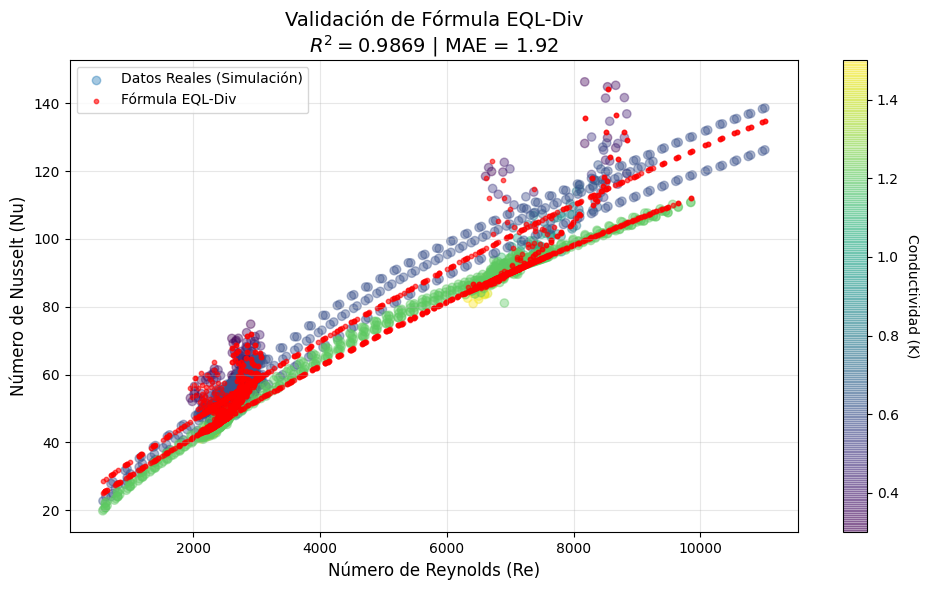

------------------------------
REPORTE DE DESEMPEÑO
------------------------------
R^2 Score:         0.98694
Error Medio Abs.:  1.9161
Error Porcentual:  3.13%
------------------------------
Interpretación:
Si los puntos rojos siguen la trayectoria de los puntos de colores,
la fórmula ha capturado exitosamente la física del problema.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ==============================================================================
# 1. TU FÓRMULA TRANSCRITA
# ==============================================================================
def formula_eql_div(x1, x3):
    """
    x1: Reynolds Normalizado
    x3: K (Conductividad) Normalizada
    """
    # Términos del numerador
    # Nota: x1 * (... x1 ... x3) implica interacción cuadrática y cruzada
    term1 = 0.0769757388424867 * x1 * (-0.197311401367188 * x1 - 0.1654282361269 * x3)
    term2 = 0.274893658900565 * x1
    term3 = 0.00559142152813967 * x3**4
    term4 = -0.0373192877938784 * x3
    
    numerator = term1 + term2 + term3 + term4
    
    # Denominador
    denominator = 0.268660396337509 - 0.00200741071083692 * x3**4
    
    return numerator / denominator

# ==============================================================================
# 2. CARGA DE DATOS
# ==============================================================================
# Intentamos cargar el archivo (ajusta la ruta si es necesario)
rutas_posibles = [
    "df_n_25.txt", 
    "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"
]

data = None
for r in rutas_posibles:
    try:
        data = pd.read_csv(r)
        print(f"--> Datos cargados desde: {r}")
        break
    except:
        continue

if data is None:
    # Generar error si no se encuentra, o usar dummy para probar que el código corre
    raise FileNotFoundError("No se encontró 'df_n_25.txt'. Verifica la ruta.")

# Limpieza básica
data = data.dropna()
# Filtro físico (valores positivos)
data = data[(data['Rem'] > 0) & (data['nusselt'] > 0)].copy()

# Variables Físicas Reales
Re_real = data['Rem'].values
K_real  = data['K'].values
Nu_real = data['nusselt'].values

# ==============================================================================
# 3. NORMALIZACIÓN (El puente EQL)
# ==============================================================================
# Calculamos las estadísticas de los datos reales para traducir
mu_Re, std_Re = Re_real.mean(), Re_real.std() + 1e-6
mu_K,  std_K  = K_real.mean(),  K_real.std()  + 1e-6
mu_Nu, std_Nu = Nu_real.mean(), Nu_real.std() + 1e-6

# Generamos las entradas normalizadas para la fórmula
x1_input = (Re_real - mu_Re) / std_Re
x3_input = (K_real  - mu_K)  / std_K

# ==============================================================================
# 4. PREDICCIÓN
# ==============================================================================

# A) Calcular Nusselt normalizado usando tu fórmula
y_pred_norm = formula_eql_div(x1_input, x3_input)

# B) Des-normalizar para obtener Nusselt Real
Nu_pred = y_pred_norm * std_Nu + mu_Nu

# C) Métricas de desempeño
r2 = r2_score(Nu_real, Nu_pred)
mae = np.mean(np.abs(Nu_real - Nu_pred))
pe  = np.mean(np.abs((Nu_real - Nu_pred) / Nu_real)) * 100 # Error porcentual

# ==============================================================================
# 5. GRÁFICO (Nu vs Re)
# ==============================================================================
plt.figure(figsize=(10, 6))

# A) Datos Reales (Scatter con mapa de color según K)
sc = plt.scatter(Re_real, Nu_real, c=K_real, cmap='viridis', 
                 alpha=0.4, label='Datos Reales (Simulación)')
cbar = plt.colorbar(sc)
cbar.set_label('Conductividad (K)', rotation=270, labelpad=15)

# B) Predicción de la Fórmula (Puntos Rojos)
plt.scatter(Re_real, Nu_pred, c='red', s=10, alpha=0.6, label='Fórmula EQL-Div')

# Etiquetas y Títulos
plt.title(f'Validación de Fórmula EQL-Div\n$R^2 = {r2:.4f}$ | MAE = {mae:.2f}', fontsize=14)
plt.xlabel('Número de Reynolds (Re)', fontsize=12)
plt.ylabel('Número de Nusselt (Nu)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. REPORTE
# ==============================================================================
print("-" * 30)
print("REPORTE DE DESEMPEÑO")
print("-" * 30)
print(f"R^2 Score:         {r2:.5f}")
print(f"Error Medio Abs.:  {mae:.4f}")
print(f"Error Porcentual:  {pe:.2f}%")
print("-" * 30)
print("Interpretación:")
print("Si los puntos rojos siguen la trayectoria de los puntos de colores,")
print("la fórmula ha capturado exitosamente la física del problema.")

--> Iniciando proceso para DATOS DE BATERÍAS
--> Archivo cargado correctamente.
--> Datos procesados: 3690 muestras. Inputs: 3
--> Archivos guardados en: C:/Users/Benjamin/EQL_Tensorflow\data
--> Ejecutando train.py vía subprocess...
--> Entrenamiento finalizado con éxito.

--- FÓRMULA DESCUBIERTA (BATERÍAS) ---
Mostrando fórmula LaTeX renderizada:


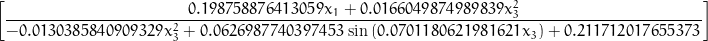


PROCESO TERMINADO.


In [1]:
import os
import shutil
import pickle
import gzip
import subprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

# --- 1. CONFIGURACIÓN DE RUTAS Y PARÁMETROS ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 
DATA_FILE = "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"

# Importante: Agregamos "div" para EQL-Div y "id" para pasar variables limpias
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "div", "log","sqrt"]

# Configuración ajustada para física (Baterías)
BATTERY_CONFIG = {
    "id": "Battery_Nu",    
    "num_h_layers": 1,     
    "layer_width": 2,      
    "batch_size": 32,
    "learning_rate": 0.001, 
    "reg_scale": 0.001,    
    "epochs": 5000,        
    "generate_symbolic_expr": True,
    "train_val_split": 0.8,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

# --- 2. CARGA Y PREPARACIÓN DE DATOS ---
if not os.path.exists(EQL_PATH):
    print(f"ERROR CRÍTICO: No se encuentra la carpeta del repositorio en {EQL_PATH}")
else:
    print(f"--> Iniciando proceso para DATOS DE BATERÍAS")
    
    # A) Cargar DataFrame
    try:
        # Intentamos cargar con la ruta completa, si falla buscamos local
        if os.path.exists(DATA_FILE):
            df = pd.read_csv(DATA_FILE)
        else:
            # Fallback: intentar leer localmente si subiste el archivo al entorno
            df = pd.read_csv("df_n_25.txt")
        
        print("--> Archivo cargado correctamente.")
        
        # B) Limpieza Física (Evitar log/div por cero)
        df = df.dropna()
        mask = (df['Rem'] > 0) & (df['prandtl'] > 0) & (df['nusselt'] > 0)
        df_clean = df[mask].copy()
        
        # C) Definir X (Inputs) e y (Output)
        # Orden: x0=Re, x1=Pr, x2=K
        inputs = ['Rem', 'prandtl', 'K']
        output = 'nusselt'
        
        X_raw = df_clean[inputs].values.astype(np.float32)
        y_raw = df_clean[output].values.reshape(-1, 1).astype(np.float32)
        
        # D) Normalización (OBLIGATORIA para EQL)
        # Guardamos estadísticas para desnormalizar después si es necesario
        X_mean, X_std = X_raw.mean(0), X_raw.std(0) + 1e-6
        y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-6
        
        X_norm = (X_raw - X_mean) / X_std
        y_norm = (y_raw - y_mean) / y_std
        
        print(f"--> Datos procesados: {X_norm.shape[0]} muestras. Inputs: 3")

        # E) Split Train/Test
        X_train, X_test, y_train, y_test = train_test_split(
            X_norm, y_norm, test_size=0.2, random_state=SEED
        )

        # --- 3. GUARDADO DE ARCHIVOS (Pickle comprimido) ---
        # EQL_Tensorflow necesita los archivos en disco
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
        
        file_name_base = "battery_data"
        path_train = os.path.join(data_dir, f"{file_name_base}_train.pkl.gz")
        path_test = os.path.join(data_dir, f"{file_name_base}_test.pkl.gz")
        
        # Guardamos tuplas (X, y) comprimidas
        with gzip.open(path_train, "wb") as f:
            pickle.dump((X_train, y_train), f)
        with gzip.open(path_test, "wb") as f:
            pickle.dump((X_test, y_test), f)
            
        print(f"--> Archivos guardados en: {data_dir}")

        # --- 4. EJECUCIÓN DEL ENTRENAMIENTO ---
        # Limpieza de resultados previos
        unique_dir = "results/Battery_Nu"
        full_result_path = os.path.join(EQL_PATH, unique_dir)
        if os.path.exists(full_result_path): 
            shutil.rmtree(full_result_path)

        # Actualizar config con las rutas relativas que espera el script
        curr_conf = BATTERY_CONFIG.copy()
        curr_conf["train_val_file"] = f"data/{file_name_base}_train.pkl.gz"
        curr_conf["test_file"]      = f"data/{file_name_base}_test.pkl.gz"
        curr_conf["model_dir"]      = unique_dir # Carpeta relativa dentro de EQL_PATH

        print(f"--> Ejecutando train.py vía subprocess...")
        
        # Llamada al sistema
        try:
            # Convertimos el dict a string para pasarlo como argumento
            subprocess.run(
                ["python", "train.py", str(curr_conf)], 
                cwd=EQL_PATH, 
                check=True, 
                capture_output=True, 
                text=True, 
                encoding='utf-8' # Importante para Windows
            )
            
            print("--> Entrenamiento finalizado con éxito.")
            
            # --- 5. VISUALIZACIÓN DE RESULTADOS ---
            print("\n--- FÓRMULA DESCUBIERTA (BATERÍAS) ---")
            
            # Buscamos la imagen generada (EQL suele generar latex_y0.png o graph_y0.png)
            png_latex = os.path.join(full_result_path, "latex_y0.png")
            png_graph = os.path.join(full_result_path, "graph_y0.png")
            
            if os.path.exists(png_latex):
                print("Mostrando fórmula LaTeX renderizada:")
                display(Image(filename=png_latex))
            elif os.path.exists(png_graph):
                print("Mostrando grafo computacional:")
                display(Image(filename=png_graph))
            else:
                print("X - No se encontró la imagen de la fórmula. Revisa la carpeta 'results'.")
                # Intentar leer el log o archivo de texto si existe
                formula_file = os.path.join(full_result_path, "formula_y0.txt")
                if os.path.exists(formula_file):
                    with open(formula_file, 'r') as f:
                        print("Fórmula en texto:", f.read())

        except subprocess.CalledProcessError as e:
            print(f"ERROR en subprocess train.py.")
            print("Salida de error (últimas líneas):")
            if e.stderr:
                print('\n'.join(e.stderr.split('\n')[-10:]))
            else:
                print("No se capturó stderr. Revisa si python está en el PATH.")

    except Exception as e:
        print(f"Error general procesando los datos: {e}")

print("\nPROCESO TERMINADO.")

--> Datos cargados desde: C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt


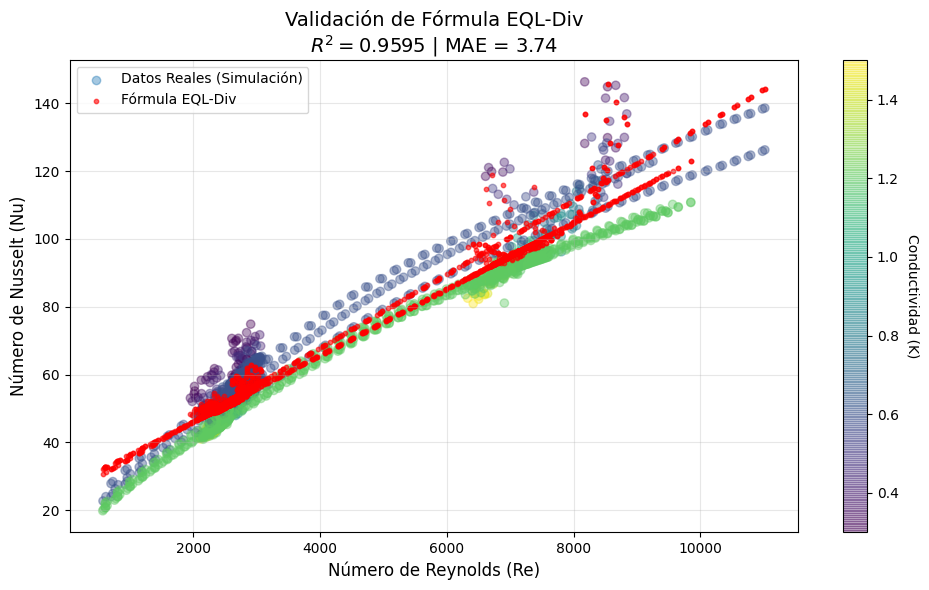

------------------------------
REPORTE DE DESEMPEÑO
------------------------------
R^2 Score:         0.95951
Error Medio Abs.:  3.7385
Error Porcentual:  6.68%
------------------------------


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ==============================================================================
# 1. TU FÓRMULA (EQL-Div)
# ==============================================================================
def formula_eql_div(x1, x3):
    """
    x1: Reynolds Normalizado
    x3: K (Conductividad) Normalizada
    """

    
    return (0.198758876413059 * x1 + 0.0166049874989839 * x3**2) / (-0.0130385840909329 * x3**2 + 0.0626987740397453 * np.sin(0.0701180621981621 * x3) + 0.211712017655373)

# ==============================================================================
# 2. CARGA DE DATOS
# ==============================================================================
# Rutas de búsqueda (ajusta si es necesario)
rutas = [
    "df_n_25.txt", 
    "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"
]

data = None
for r in rutas:
    try:
        data = pd.read_csv(r)
        print(f"--> Datos cargados desde: {r}")
        break
    except:
        continue

if data is None:
    # Generar error si no se encuentra
    raise FileNotFoundError("No se encontró 'df_n_25.txt'. Verifica la ruta.")

# Limpieza básica
data = data.dropna()
# Filtro físico (valores positivos)
data = data[(data['Rem'] > 0) & (data['nusselt'] > 0)].copy()

# Variables Físicas Reales
Re_real = data['Rem'].values
K_real  = data['K'].values
Nu_real = data['nusselt'].values

# ==============================================================================
# 3. NORMALIZACIÓN (El puente entre Física y Modelo)
# ==============================================================================
# Calculamos las estadísticas de los datos reales para traducir
mu_Re, std_Re = Re_real.mean(), Re_real.std() + 1e-6
mu_K,  std_K  = K_real.mean(),  K_real.std()  + 1e-6
mu_Nu, std_Nu = Nu_real.mean(), Nu_real.std() + 1e-6

# Generamos las entradas normalizadas para la fórmula (x1, x3)
x1_input = (Re_real - mu_Re) / std_Re
x3_input = (K_real  - mu_K)  / std_K

# ==============================================================================
# 4. PREDICCIÓN
# ==============================================================================

# A) Calcular Nusselt normalizado usando tu fórmula
y_pred_norm = formula_eql_div(x1_input, x3_input)

# B) Des-normalizar para obtener Nusselt Real
Nu_pred = y_pred_norm * std_Nu + mu_Nu

# C) Métricas de desempeño
# Manejo de NaNs/Infinitos por si el denominador se acercó a cero
mask_valid = np.isfinite(Nu_pred)
if np.sum(mask_valid) < len(Nu_pred):
    print(f"¡ADVERTENCIA! Se encontraron {len(Nu_pred) - np.sum(mask_valid)} valores infinitos/NaN.")
    # Filtramos para calcular métricas
    Nu_real_m = Nu_real[mask_valid]
    Nu_pred_m = Nu_pred[mask_valid]
else:
    Nu_real_m = Nu_real
    Nu_pred_m = Nu_pred

r2 = r2_score(Nu_real_m, Nu_pred_m)
mae = np.mean(np.abs(Nu_real_m - Nu_pred_m))
pe  = np.mean(np.abs((Nu_real_m - Nu_pred_m) / Nu_real_m)) * 100 # Error porcentual

# ==============================================================================
# 5. GRÁFICO (Nu vs Re)
# ==============================================================================
plt.figure(figsize=(10, 6))

# A) Datos Reales (Scatter con mapa de color según K)
sc = plt.scatter(Re_real, Nu_real, c=K_real, cmap='viridis', 
                 alpha=0.4, label='Datos Reales (Simulación)')
cbar = plt.colorbar(sc)
cbar.set_label('Conductividad (K)', rotation=270, labelpad=15)

# B) Predicción de la Fórmula (Puntos Rojos)
plt.scatter(Re_real, Nu_pred, c='red', s=10, alpha=0.6, label='Fórmula EQL-Div')

# Etiquetas y Títulos
plt.title(f'Validación de Fórmula EQL-Div\n$R^2 = {r2:.4f}$ | MAE = {mae:.2f}', fontsize=14)
plt.xlabel('Número de Reynolds (Re)', fontsize=12)
plt.ylabel('Número de Nusselt (Nu)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. REPORTE
# ==============================================================================
print("-" * 30)
print("REPORTE DE DESEMPEÑO")
print("-" * 30)
print(f"R^2 Score:         {r2:.5f}")
print(f"Error Medio Abs.:  {mae:.4f}")
print(f"Error Porcentual:  {pe:.2f}%")
print("-" * 30)